# Trabajo 2 
## Inteligencia Artificial para la Ciencia de los Datos

Trabajo realizado por:

**Manuel Enciso Martínez**


Vamos a usar para el trabajo Annealing [Dataset].  UCI Machine Learning Repository. https://doi.org/10.24432/C5RW2F.

El dataset tiene como objetivo predicir el tipo de aleación del acero. Para ello, se disponen de $38$ atributos de los cuales:
* $6$ contienen valores continuos
* $3$ contienen valores enteros
* $29$ contienen valores nominales

Además de contener valores Nan representados mediante '?', también existen valores no aplicables representados mediante '-' (habrá que diferenciarlos en el preprocesado).

En la siguiente tabla, obtenida a partir de la información proporcionada en el dataset, se muestran los distintos atributos y tipos:

| #  | Variable               | Tipo                | Valores posibles                       |
| -- | ---------------------- | ------------------- | -------------------------------------- |
| 1  | family                 | Categórica          | --, GB, GK, GS, TN, ZA, ZF, ZH, ZM, ZS |
| 2  | product-type           | Categórica          | C, H, G                                |
| 3  | steel                  | Categórica          | -, R, A, U, K, M, S, W, V              |
| 4  | carbon                 | Numérica continua   | [0.0, ∞)                               |
| 5  | hardness               | Numérica continua   | [0.0, ∞)                               |
| 6  | temper_rolling         | Categórica binaria  | -, T                                   |
| 7  | condition              | Categórica          | -, S, A, X                             |
| 8  | formability            | Ordinal             | -, 1, 2, 3, 4, 5                       |
| 9  | strength               | Numérica continua   | [0.0, ∞)                               |
| 10 | non-ageing             | Categórica binaria  | -, N                                   |
| 11 | surface-finish         | Categórica          | P, M, -                                |
| 12 | surface-quality        | Categórica          | -, D, E, F, G                          |
| 13 | enamelability          | Ordinal             | -, 1, 2, 3, 4, 5                       |
| 14 | bc                     | Categórica binaria  | Y, -                                   |
| 15 | bf                     | Categórica binaria  | Y, -                                   |
| 16 | bt                     | Categórica binaria  | Y, -                                   |
| 17 | bw/me                  | Categórica          | B, M, -                                |
| 18 | bl                     | Categórica binaria  | Y, -                                   |
| 19 | m                      | Categórica binaria  | Y, -                                   |
| 20 | chrom                  | Categórica binaria  | C, -                                   |
| 21 | phos                   | Categórica binaria  | P, -                                   |
| 22 | cbond                  | Categórica binaria  | Y, -                                   |
| 23 | marvi                  | Categórica binaria  | Y, -                                   |
| 24 | exptl                  | Categórica binaria  | Y, -                                   |
| 25 | ferro                  | Categórica binaria  | Y, -                                   |
| 26 | corr                   | Categórica binaria  | Y, -                                   |
| 27 | blue/bright/varn/clean | Categórica          | B, R, V, C, -                          |
| 28 | lustre                 | Categórica binaria  | Y, -                                   |
| 29 | jurofm                 | Categórica binaria  | Y, -                                   |
| 30 | s                      | Categórica binaria  | Y, -                                   |
| 31 | p                      | Categórica binaria  | Y, -                                   |
| 32 | shape                  | Categórica binaria  | COIL, SHEET                            |
| 33 | thick                  | Numérica continua   | [0.0, ∞)                               |
| 34 | width                  | Numérica continua   | [0.0, ∞)                               |
| 35 | len                    | Numérica continua   | [0.0, ∞)                               |
| 36 | oil                    | Categórica          | -, Y, N                                |
| 37 | bore                   | Categórica ordinal  | 0000, 0500, 0600, 0760                 |
| 38 | packing                | Ordinal             | -, 1, 2, 3                             |
| 39 | class                  | Target (multiclase) | 1, 2, 3, 4, 5, U                       |

### Exploración, visualización y limpieza

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# Ruta del directorio actual del notebook
BASE_DIR = Path.cwd()

DATA_TEST_PATH = BASE_DIR / "anneal.test"
DATA_PATH = BASE_DIR / "anneal.data"

# Cargar los datos
df_train = pd.read_csv(DATA_PATH)
df_test = pd.read_csv(DATA_TEST_PATH)
print("Tamaño del conjunto de entrenamiento:",np.shape(df_train))
print("Tamaño del conjunto de test:",np.shape(df_test))

Tamaño del conjunto de entrenamiento: (797, 39)
Tamaño del conjunto de test: (99, 39)


Como nuestro dataframe no contiene el nombre de los atributos, para facilitar la comprensión vamos a añadir el nombre correspondiente a cada columna.

In [2]:
column_names = [
    'family', 'product-type', 'steel', 'carbon', 'hardness',
    'temper_rolling', 'condition', 'formability', 'strength', 'non-ageing',
    'surface-finish', 'surface-quality', 'enamelability', 'bc', 'bf',
    'bt', 'bw/me', 'bl', 'm', 'chrom',
    'phos', 'cbond', 'marvi', 'exptl', 'ferro',
    'corr', 'blue/bright/varn/clean', 'lustre', 'jurofm', 's',
    'p', 'shape', 'thick', 'width', 'len',
    'oil', 'bore', 'packing', 'class'
]

df_train.columns = column_names
df_test.columns = column_names

df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True) # Vamos a juntar ambos dataframes (más adelante explicaremos el motivo)
print("Tamaño del conjunto:",np.shape(df))
print("\n")
df.head()

Tamaño del conjunto: (896, 39)




,family,product-type,steel,carbon,hardness,temper_rolling,condition,formability,strength,non-ageing,...,s,p,shape,thick,width,len,oil,bore,packing,class
0,?,C,R,0,0,?,S,2,0,?,...,?,?,COIL,3.200,610.0,0,?,0,?,3
1,?,C,R,0,0,?,S,2,0,?,...,?,?,SHEET,0.700,1300.0,762,?,0,?,3
2,?,C,A,0,60,T,?,?,0,?,...,?,?,COIL,2.801,385.1,0,?,0,?,3
3,?,C,A,0,60,T,?,?,0,?,...,?,?,SHEET,0.801,255.0,269,?,0,?,3
4,?,C,A,0,45,?,S,?,0,?,...,?,?,COIL,1.600,610.0,0,?,0,?,3


Visualicemos el balanceamiento de clases.

In [3]:
df['class'].value_counts()

class
3    682
2     99
5     67
U     40
1      8
Name: count, dtype: int64

In [4]:
607/(88+60+34+8)

3.194736842105263

Observamos que el dataset presenta un desbalanceamiento moderado, siendo la clase *3* tres veces más poblada que la suma del resto de clases.

Veamos a continuación cuantos valores NaN presenta nuestro dataset.

In [5]:
df.eq('?').sum()

family                    770
product-type                0
steel                      86
carbon                      0
hardness                    0
temper_rolling            759
condition                 303
formability               316
strength                    0
non-ageing                791
surface-finish            887
surface-quality           244
enamelability             880
bc                        895
bf                        767
bt                        822
bw/me                     685
bl                        747
m                         896
chrom                     870
phos                      889
cbond                     822
marvi                     896
exptl                     894
ferro                     866
corr                      896
blue/bright/varn/clean    890
lustre                    845
jurofm                    896
s                         896
p                         896
shape                       0
thick                       0
width     

El dataset presenta multitud de valores NaN para multitud de columnas, una falta de información drástica. 

En particular, destacar que los siguientes atributos no contienen valores:
* p,s, jurofm, m, marvi, corr

Y existen otras columnas con menos de 100 instancias no nulas.

Tan solo las siguientes columnas contienen valores para todas las instancias:
* bore, len, width, thick, shape, product-type, carbon, hardness, strength y la clase objetivo.

Visualicemos mediante gráficas de barras e histogramas los distintos valores que toman cada atributo.

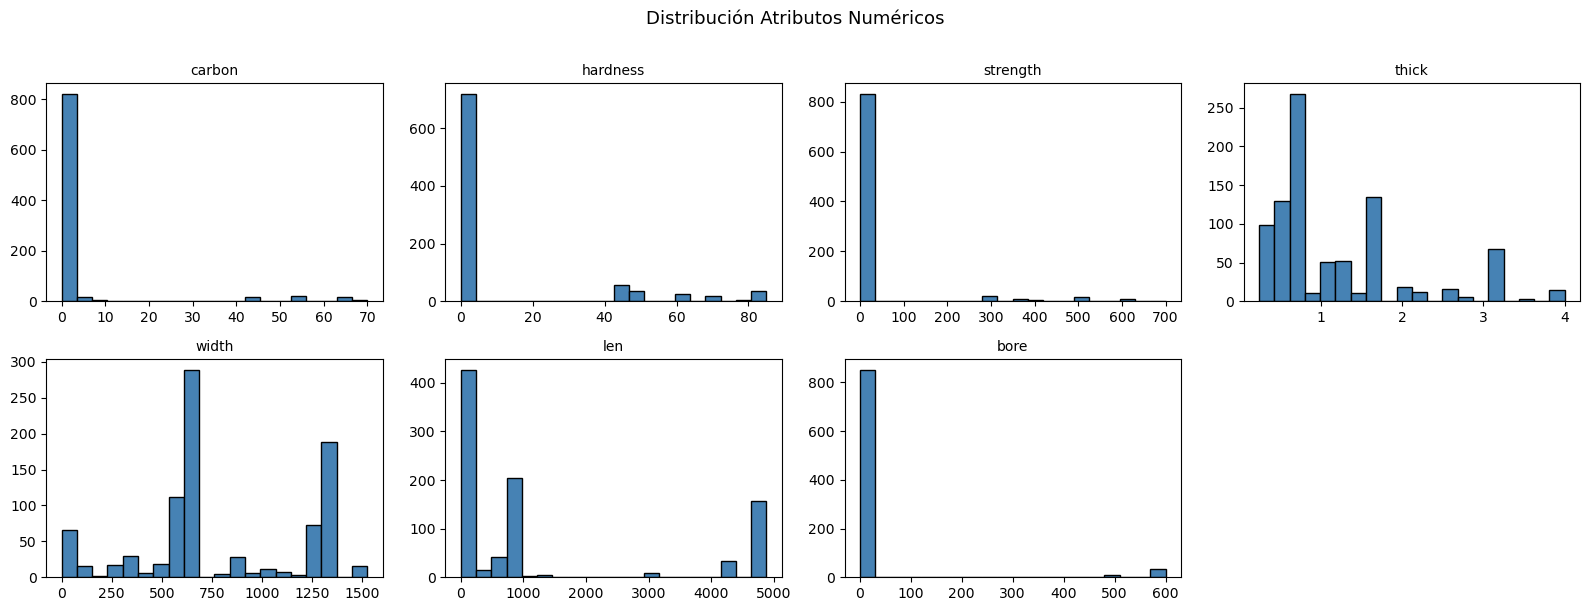

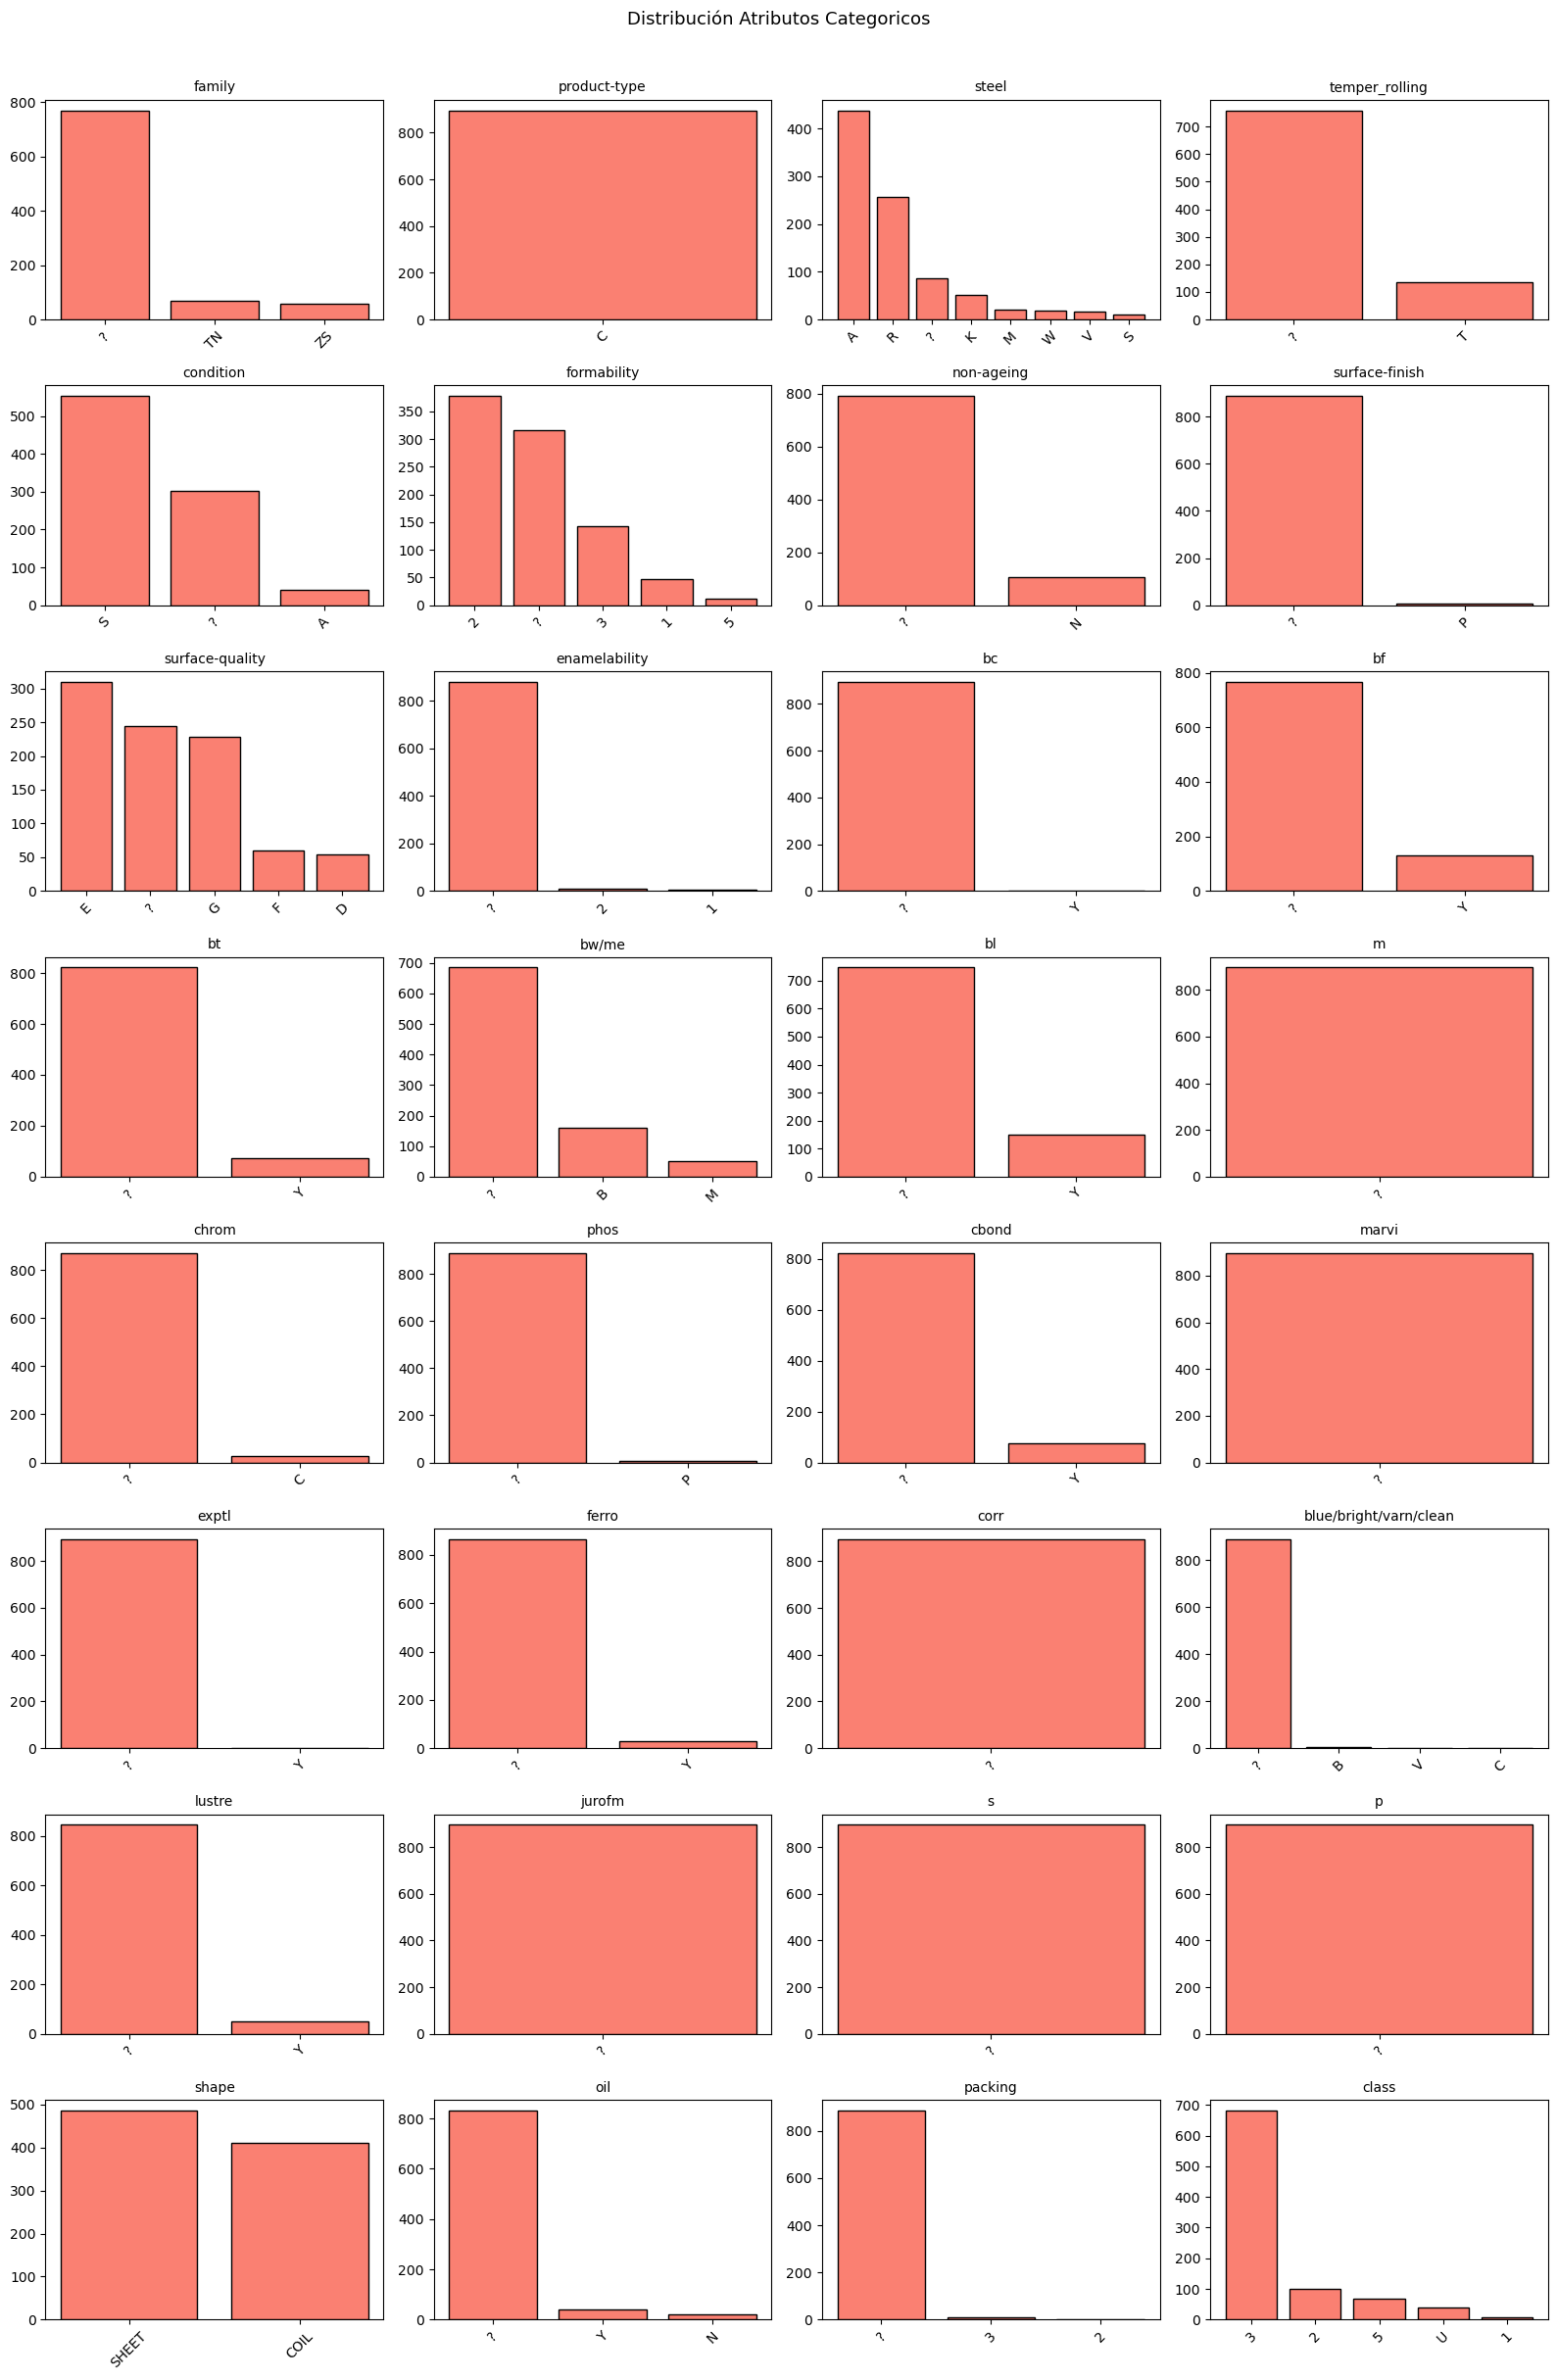

In [6]:
import matplotlib.pyplot as plt
import math

# Distinguimos atribyutos tipo numérico de categoricos, para representarlos en histogramas o barras respectivamente
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categ_cols   = df.select_dtypes(include='object').columns.tolist()

def plot_distributions(cols, df, plot_type='hist', title_prefix=''):
    n = len(cols)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        if plot_type == 'hist':
            data = df[col].dropna()
            ax.hist(data, bins=20, edgecolor='black', color='steelblue')
        else:
            counts = df[col].value_counts()
            ax.bar(counts.index.astype(str), counts.values, edgecolor='black', color='salmon')
            ax.tick_params(axis='x', rotation=45)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('')

    # Ocultar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{title_prefix}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Atributos numéricos
plot_distributions(numeric_cols, df, plot_type='hist', title_prefix='Distribución Atributos Numéricos')

#  Atributos categoricos
plot_distributions(categ_cols, df, plot_type='bar', title_prefix='Distribución Atributos Categoricos')

Destacar que la clasificación en ''clase = 4'' no tiene ninguna representación.

#### Recuperación de valores ausentes vs no aplicables
**Inconveniente principal:** Resulta que los valores '-' (no aplicable) y '?' (ausente) se han fusionado en el dataset por '?'. No he encontrado ninguna versión antigua que distinga ambos casos, en todas las versiones se fusionan ambas casos por '?'.

Como en las instrucciones indican que no deberia tratarse por igual, vamos a aplicar una técnica heuristica para tratar de recuperar la distinción de 'Valor no aplicable' frente a 'Valor ausente'

Vamos a intentar usar un modelo para distinguir los '?' de **no aplicable** vs **ausente**. Para ello usamos un árbol de decisión, con una profundidad reducidad (para evitar sobreajustar) y como variable objetivo la columna que queremos distinguir.

He considerado eliminar la columna 'class' para evitar DataLeak. Aunque también sería conveniente observar si existe alguna relación con la clase y que cierto atributo pueda o no tomar valores.

Vamos a filtrar el conjunto total de datos 'df' para procesar el conjunto total de datos con la mayor información dada posible.

In [7]:
df_tree = df.drop(columns=['class']).copy()

##### Vamos a comenzar con el atributo ```steel```

Ya que es el atributo que contiene un menor número de '?'

In [8]:
df_tree_steel = df_tree.copy()

df_tree_steel['steel'] = np.where(df['steel'] == '?', 0, 1)

Para entrenar el árbol con Scikit-Learn, antes pasamos los atributos categóricos a ordinales.

In [9]:
from sklearn.preprocessing import OrdinalEncoder

# Separar features y target
X = df_tree_steel.drop(columns=['steel'])
y = df_tree_steel['steel']

# Transformar columnas categóricas 
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype(str)  

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = encoder.fit_transform(X[cat_cols])

Entrenamos un árbol a predecir $1$ si el atributo 'steel' tiene algún valor y $0$ si toma '?'

Lo que nos interesa es lograr que si el árbol obtiene un exito del 100% implica que las variables que predice como '?' no son valores ausentes sino que corresponden con valores 'no aplicable' (ya que entendemos que si el árbol ha encontrado un patron que impide que la varible correspondiente 'steel' para una instancia obtenga un valor correspondiente).

> La idea que hay detrás es la siguiente: para un dataset donde un atributo mide embarazo si/no y otro atributo indica sexo masculo/femenino. Si observamos que hay instancias '?' en el atributo embarazo y queremos distinguir "no aplicable" de "ausente", entrenamos un árbol de decisión y encuentra que si se filtra por sexo masculo obtiene un rendimiento del 100% cuando clasifica con el valor '?'. Por lo que, para estas instancais con sexo = masculo tenemos que '?' corresponde con "no aplicable" y si se filtra por sexo femenino el valor '?' corresponde con "ausente" (NaN) porque en ocasiones aparece vacío y otras puede que no.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Conjuntos train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)

# Entrenar árbol con profundidad máxima 4
clf = DecisionTreeClassifier(max_depth=4, random_state=2026)
clf.fit(X_train, y_train)

# Evaluar sobre todo el conjunto
# La idea es que aunque se entrene un árbol con train (para evitar sobreajuste) luego cuando se proceda
# a evaluar se haga con todo el conjunto (train + test) para comprobar si se verifica la regla
# obtenida para todos los datos obtenidos (y no se debe al sobreajuste)
y_pred = clf.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.65      0.79        86
           1       0.96      1.00      0.98       810

    accuracy                           0.97       896
   macro avg       0.98      0.83      0.89       896
weighted avg       0.97      0.97      0.96       896



Observamos que nuestro árbol obtiene un buen rendimiento de predecir '?', pero no logra distinguir el 100%. Es importante resultar que la predicción se ha hecho con el conjunto total (entrenamiento + test), debido a que lo que tratamos de comprobar es que todas las instancias verifican un patrón y no solo las del conjunto de test.

Veamos como se ramifíca el árbol obtenido.

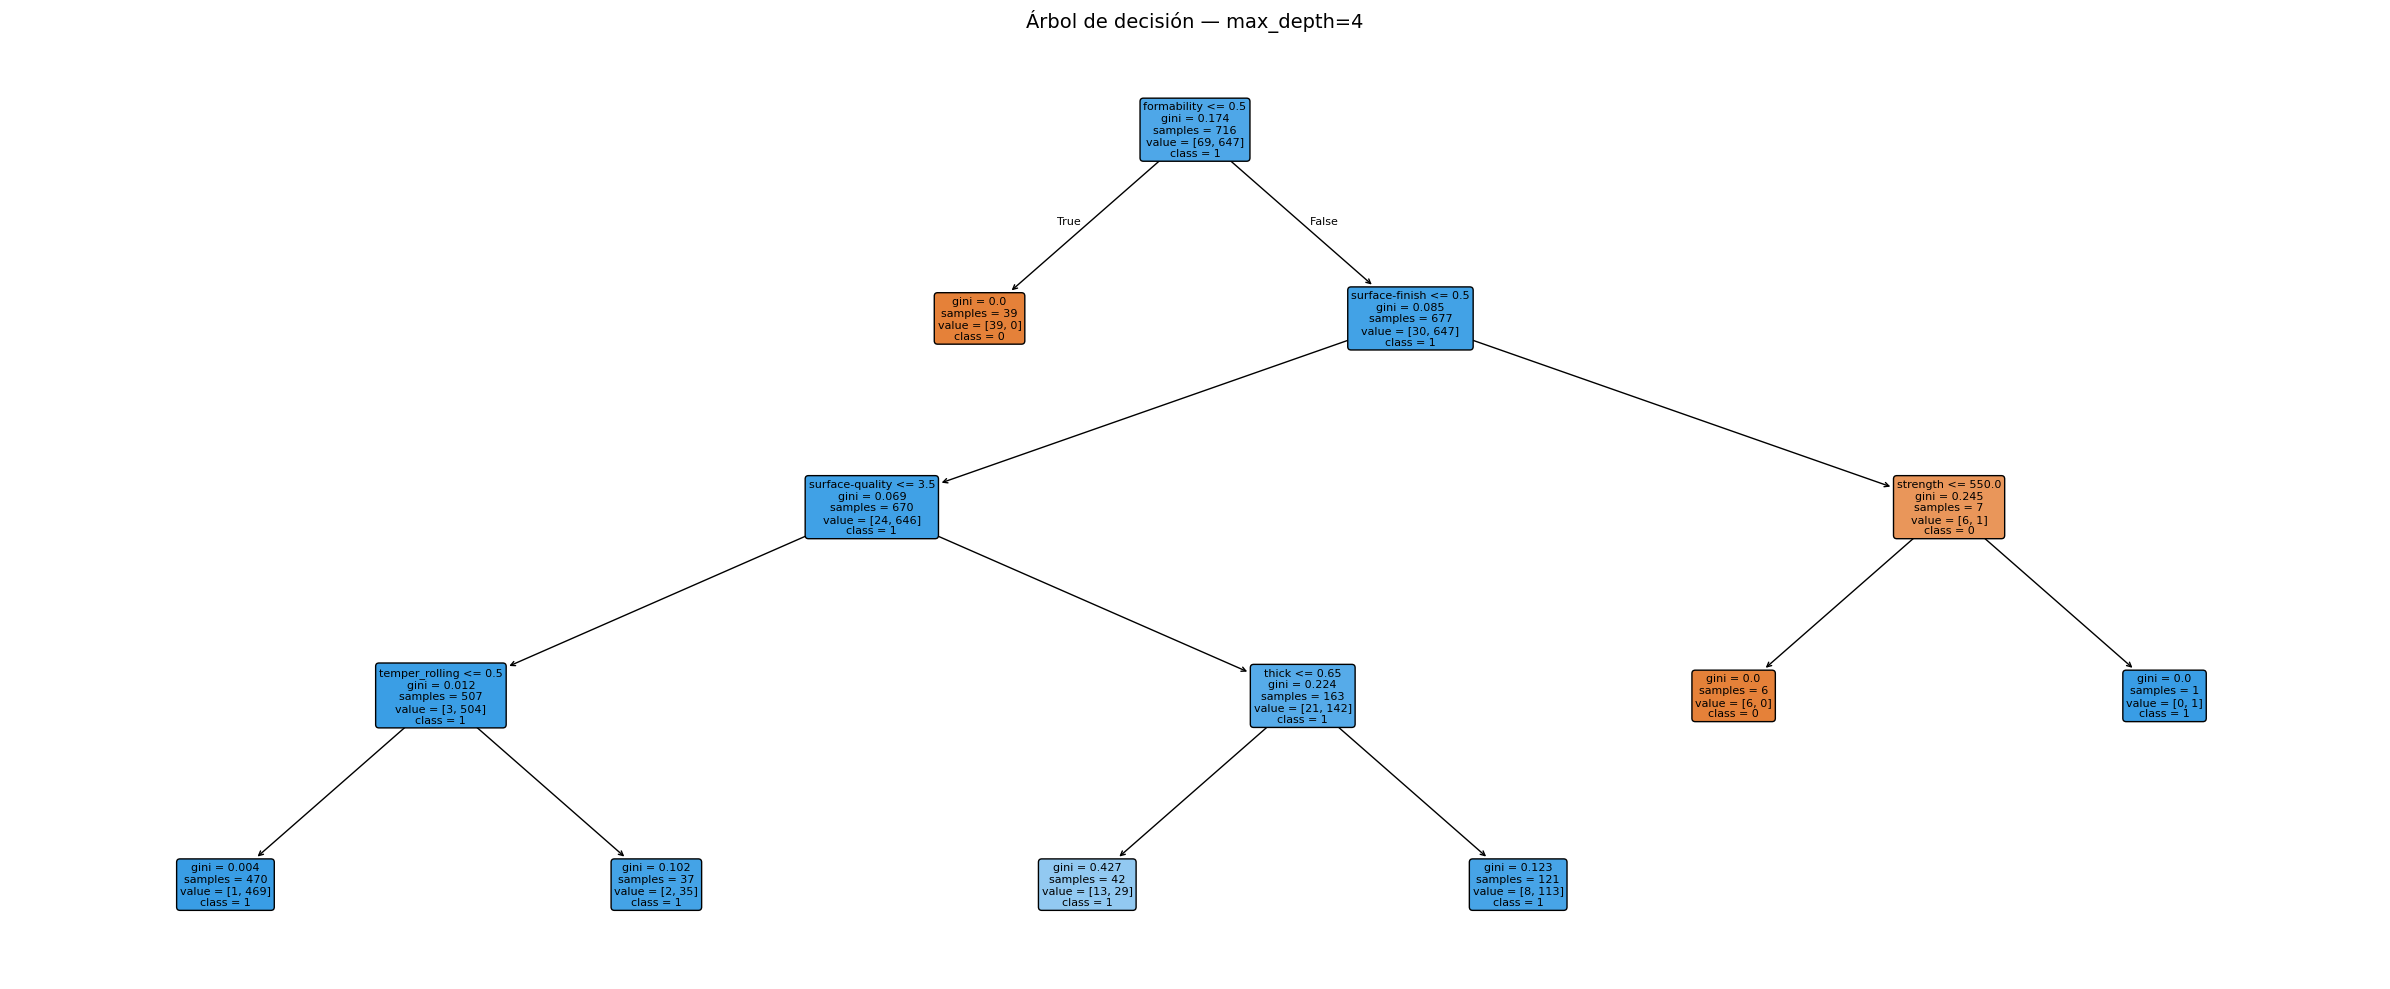

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 10))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=clf.classes_.astype(str).tolist(),
    filled=True,       # colorea según clase mayoritaria
    rounded=True,
    impurity=True,     # muestra gini de cada nodo
    proportion=False,  # muestra conteos absolutos (no proporciones)
    fontsize=8
)
plt.title('Árbol de decisión — max_depth=4', fontsize=14)
plt.tight_layout()
plt.show()

Mostremos el rendimiento para cada nodo de clasificación.

In [12]:
# Obtener el nodo hoja al que va cada instancia de TEST
nodo_por_instancia = clf.apply(X)

# Construir DataFrame con: nodo asignado, clase real, clase predicha
df_hojas = pd.DataFrame({
    'nodo': nodo_por_instancia,
    'real': y.values,
    'predicho': y_pred
})

# Calcular precisión por nodo hoja
precision_por_hoja = df_hojas.groupby('nodo').apply(
    lambda g: pd.Series({
        'n_instancias': len(g),
        'precision': (g['real'] == g['predicho']).mean().round(3),
        'clase_predicha': g['predicho'].mode()[0],
        'clases_reales': dict(g['real'].value_counts())
    })
).reset_index()

precision_por_hoja = precision_por_hoja.sort_values('precision', ascending=False)
print(precision_por_hoja.to_string(index=False))

 nodo  n_instancias  precision  clase_predicha   clases_reales
    1            48      1.000               0         {0: 48}
   11             8      1.000               0          {0: 8}
   12             1      1.000               1          {1: 1}
    5           595      0.997               1  {1: 593, 0: 2}
    6            45      0.956               1   {1: 43, 0: 2}
    9           153      0.915               1 {1: 140, 0: 13}
    8            46      0.717               1  {1: 33, 0: 13}


C:\Users\encis\AppData\Local\Temp\ipykernel_12736\614748000.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  precision_por_hoja = df_hojas.groupby('nodo').apply(


Concluimos que el nodo 1 y 11 logran un 100% de clasificar la clase 0 -> '?'. Luego podemos interpretar que este patrón representa un las instancias con valor **no aplicable** más que **ausente** (para el resto de instancias el rendimiento no alcanza 100% por lo que interpretamos como NaN)

Vamos a aplicar la distinción del nodo 1 para separar valores '?' -> no aplicable y el resto de valores '?' del atributo 'steel' serán considerados como 'NaN'

In [13]:
# Aislar los identificadores de los nodos que son 100% puros y predicen 0 ('?')
nodos_puros_na = precision_por_hoja[
    (precision_por_hoja['precision'] == 1.0) & 
    (precision_por_hoja['clase_predicha'] == 0)
]['nodo'].tolist()

# Obtener el nodo hoja para todas las instancias del dataset completo 
nodos_dataset_completo = clf.apply(X)

# Máscara para las filas que caen en esos nodos deterministas
mascara_estructural = np.isin(nodos_dataset_completo, nodos_puros_na)

# Aplicar la transformación en df
df.loc[mascara_estructural, 'steel'] = 'No aplicable'

# Los '?' restantes que no cayeron en reglas 100% deterministas pasan a ser NaN
df['steel'] = df['steel'].replace('?', np.nan)

Veamos los nuevos valores para el atributo 'steel'

In [14]:
df['steel'][50:100]

50    No aplicable
51               R
52               A
53               A
54               R
55             NaN
56               A
57               A
58               A
59               A
60               A
61               A
62               A
63               R
64    No aplicable
65               A
66               R
67               A
68               A
69               A
70               R
71    No aplicable
72               R
73               A
74               R
75    No aplicable
76               A
77               A
78               R
79               A
80               A
81               V
82               A
83               R
84               K
85               R
86               A
87               M
88    No aplicable
89               A
90    No aplicable
91               A
92               A
93               K
94               A
95               R
96               A
97               A
98               R
99               R
Name: steel, dtype: object

##### Análogo para ```surface.quality```

              precision    recall  f1-score   support

           0       1.00      0.50      0.67       244
           1       0.84      1.00      0.92       652

    accuracy                           0.86       896
   macro avg       0.92      0.75      0.79       896
weighted avg       0.89      0.86      0.85       896



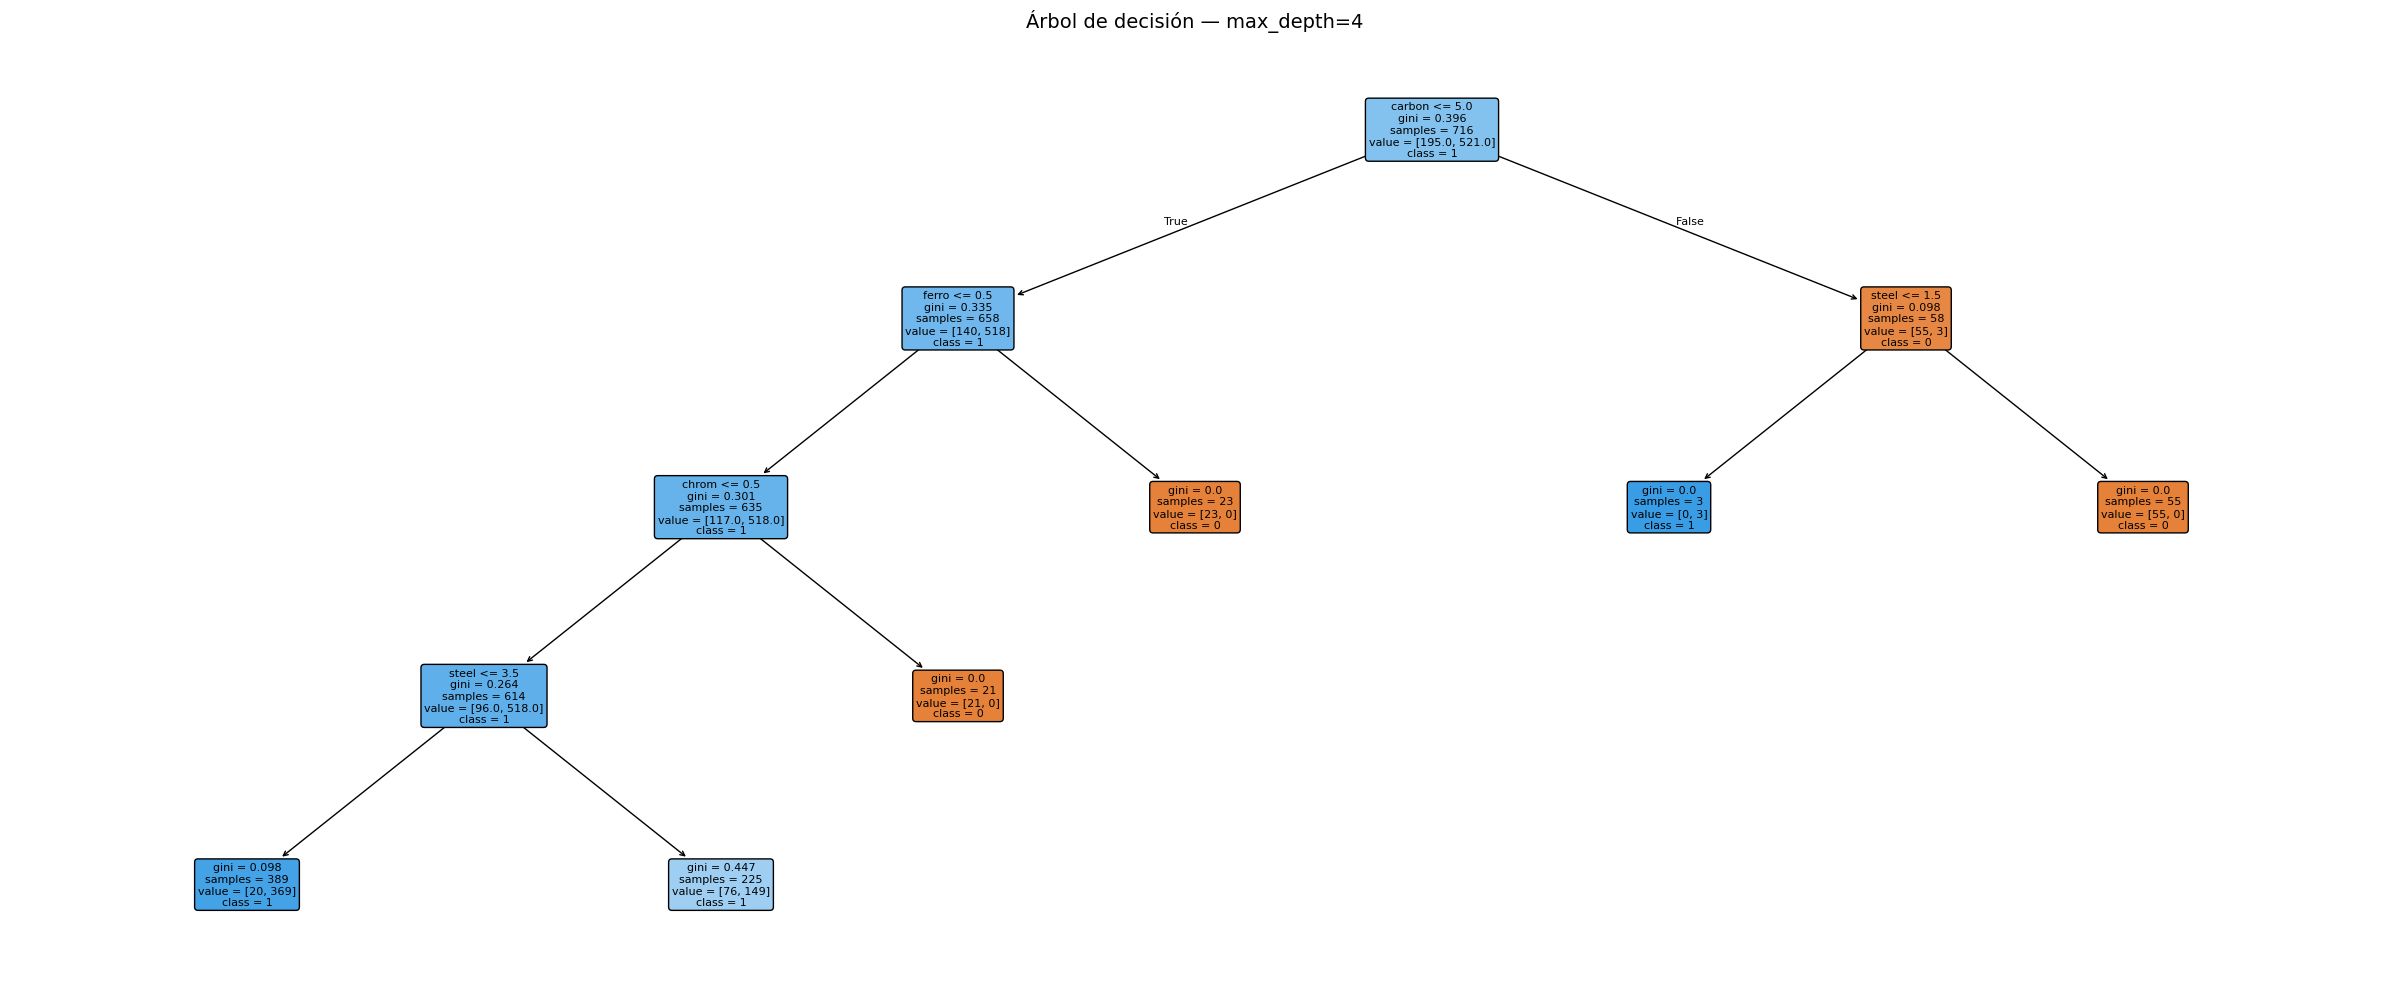

 nodo  n_instancias  precision  clase_predicha   clases_reales
    6            26      1.000               0         {0: 26}
    7            30      1.000               0         {0: 30}
    9             4      1.000               1          {1: 4}
   10            67      1.000               0         {0: 67}
    4           484      0.952               1 {1: 461, 0: 23}
    5           285      0.656               1 {1: 187, 0: 98}


C:\Users\encis\AppData\Local\Temp\ipykernel_12736\4205538246.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  precision_por_hoja = df_hojas.groupby('nodo').apply(


In [15]:
## ÁRBOL PARA surface-quality
df_tree_surface_quality = df_tree.copy()

df_tree_surface_quality['surface-quality'] = np.where(df['surface-quality'] == '?', 0, 1)


## PREPROCESADO
# Separar features y target
X = df_tree_surface_quality.drop(columns=['surface-quality'])
y = df_tree_surface_quality['surface-quality']

# Transformar columnas categóricas 
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype(str)  

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = encoder.fit_transform(X[cat_cols])


## ENTRENAMIENTO
# Conjuntos train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)

# Entrenar árbol con profundidad máxima 4
clf = DecisionTreeClassifier(max_depth=4, random_state=2026)
clf.fit(X_train, y_train)

# Evaluar
y_pred = clf.predict(X)
print(classification_report(y, y_pred))


## VISUALIZACIÓN ÁRBOL
plt.figure(figsize=(24, 10))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=clf.classes_.astype(str).tolist(),
    filled=True,       # colorea según clase mayoritaria
    rounded=True,
    impurity=True,     # muestra gini de cada nodo
    proportion=False,  # muestra conteos absolutos (no proporciones)
    fontsize=8
)
plt.title('Árbol de decisión — max_depth=4', fontsize=14)
plt.tight_layout()
plt.show()


## RENDIMIENTOS NODOS
# Obtener el nodo hoja al que va cada instancia de TEST
nodo_por_instancia = clf.apply(X)

# Construir DataFrame con: nodo asignado, clase real, clase predicha
df_hojas = pd.DataFrame({
    'nodo': nodo_por_instancia,
    'real': y.values,
    'predicho': y_pred
})

# Calcular precisión por nodo hoja
precision_por_hoja = df_hojas.groupby('nodo').apply(
    lambda g: pd.Series({
        'n_instancias': len(g),
        'precision': (g['real'] == g['predicho']).mean().round(3),
        'clase_predicha': g['predicho'].mode()[0],
        'clases_reales': dict(g['real'].value_counts())
    })
).reset_index()

precision_por_hoja = precision_por_hoja.sort_values('precision', ascending=False)
print(precision_por_hoja.to_string(index=False))

En esta ocasión ahora tenemos 3 nodos (6,7 y 10) que obtiene un 100% de rendimiento para clasificar '?'

In [16]:
# Aislar los identificadores de los nodos que son 100% puros y predicen 0 ('?')
nodos_puros_na = precision_por_hoja[
    (precision_por_hoja['precision'] == 1.0) & 
    (precision_por_hoja['clase_predicha'] == 0)
]['nodo'].tolist()

# Obtener el nodo hoja para todas las instancias del dataset completo 
nodos_dataset_completo = clf.apply(X)

# Máscara para las filas que caen en esos nodos deterministas
mascara_estructural = np.isin(nodos_dataset_completo, nodos_puros_na)

# Aplicar la transformación en df
df.loc[mascara_estructural, 'surface-quality'] = 'No aplicable'

# Los '?' restantes que no cayeron en reglas 100% deterministas pasan a ser NaN
df['surface-quality'] = df['surface-quality'].replace('?', np.nan)

In [17]:
df['surface-quality'][50:100]

50               G
51               E
52               D
53               E
54               E
55               G
56               G
57               G
58               E
59               E
60               F
61               D
62               E
63               E
64               G
65    No aplicable
66             NaN
67               E
68    No aplicable
69               G
70               E
71               G
72               E
73               G
74               E
75             NaN
76               G
77               E
78               E
79               E
80               F
81             NaN
82               G
83               E
84    No aplicable
85             NaN
86               E
87               G
88    No aplicable
89               E
90               G
91               E
92               E
93    No aplicable
94               D
95             NaN
96    No aplicable
97             NaN
98             NaN
99             NaN
Name: surface-quality, dtype: object

##### Análogo para ```condition```

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       303
           1       1.00      0.99      1.00       593

    accuracy                           1.00       896
   macro avg       1.00      1.00      1.00       896
weighted avg       1.00      1.00      1.00       896



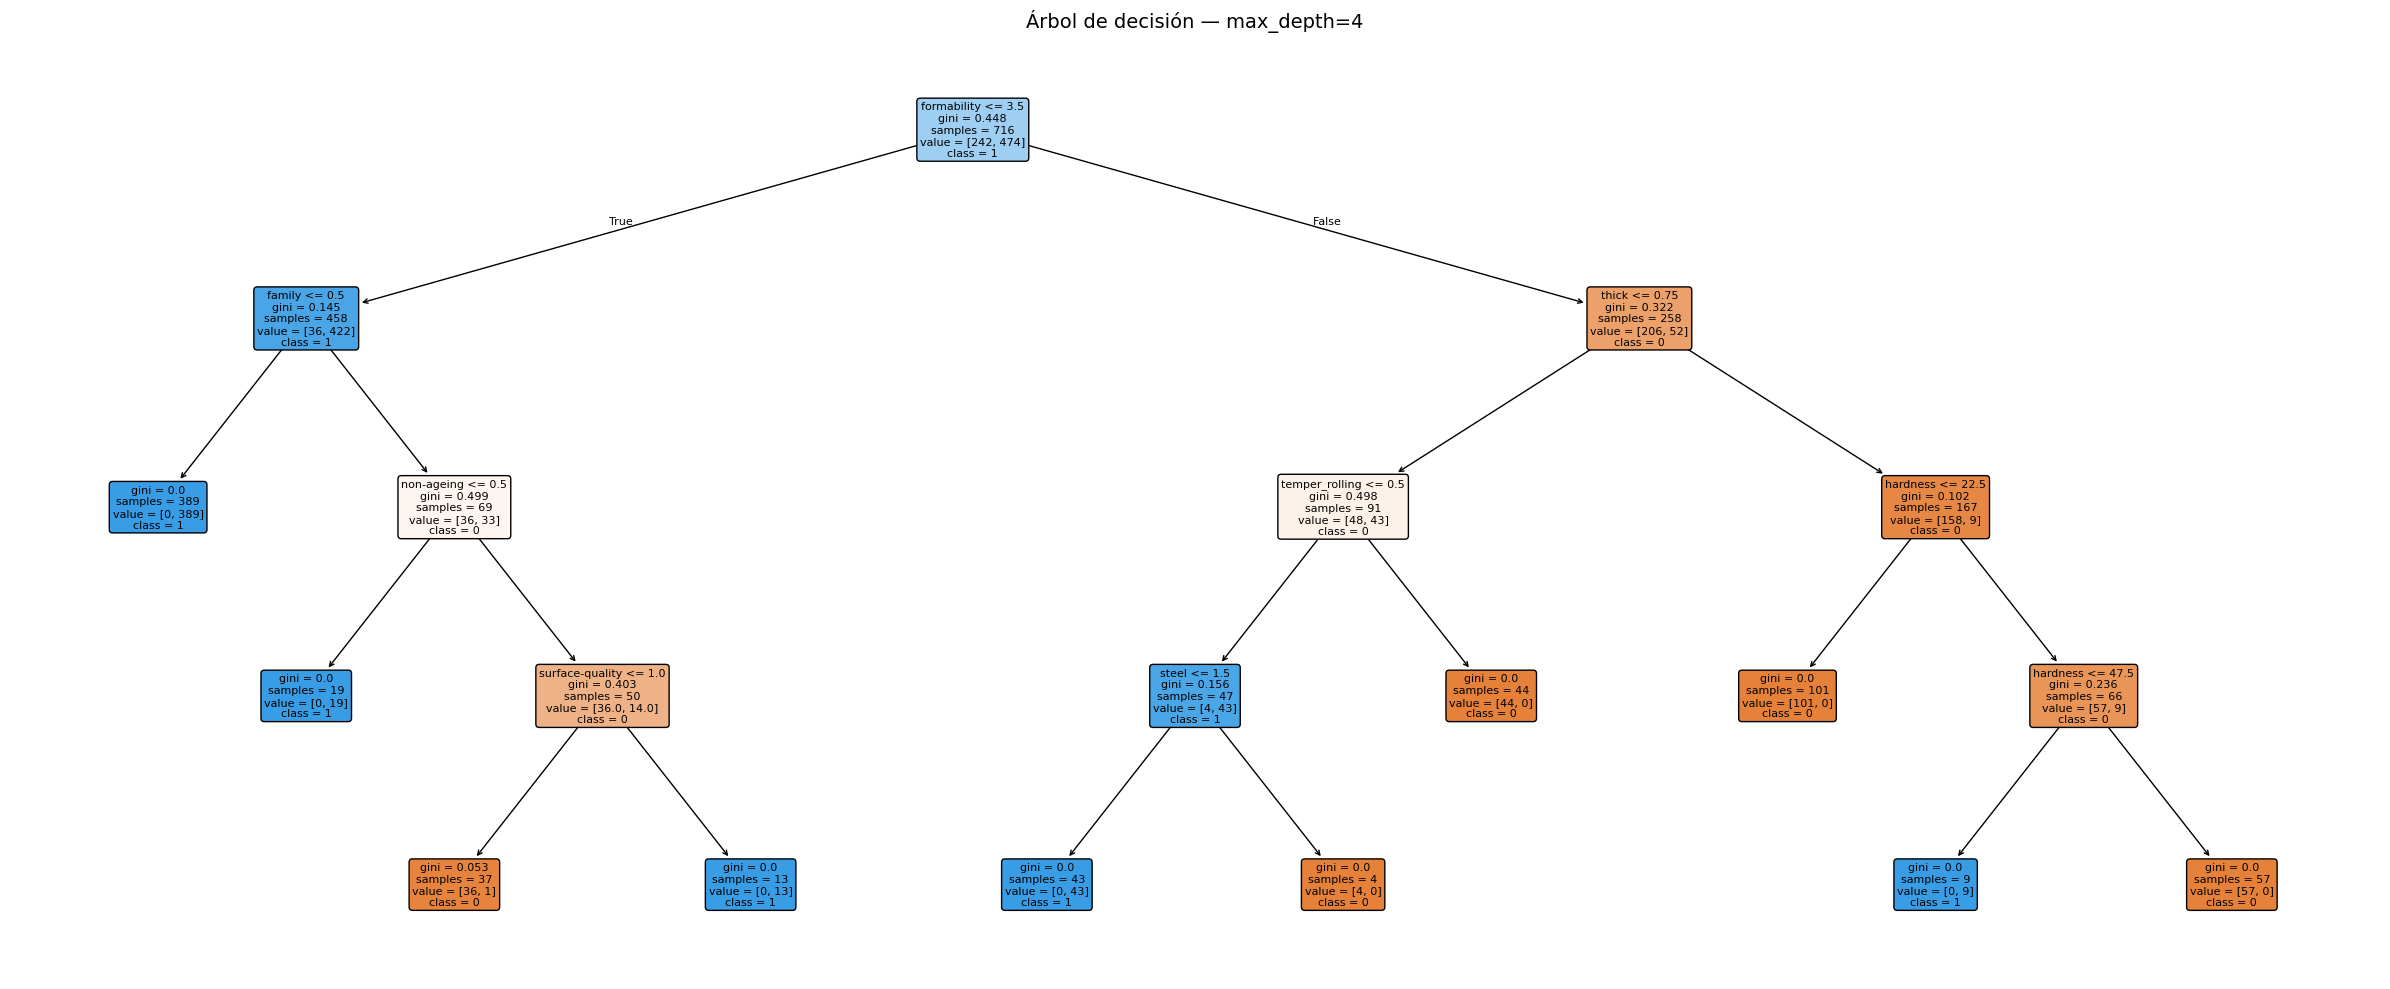

 nodo  n_instancias  precision  clase_predicha  clases_reales
    2           487      1.000               1       {1: 487}
    4            26      1.000               1        {1: 26}
    7            19      1.000               1        {1: 19}
   11            46      1.000               1        {1: 46}
   12             5      1.000               0         {0: 5}
   13            53      1.000               0        {0: 53}
   17            12      1.000               1        {1: 12}
   18            73      1.000               0        {0: 73}
   15           127      0.992               0 {0: 126, 1: 1}
    6            48      0.958               0  {0: 46, 1: 2}


C:\Users\encis\AppData\Local\Temp\ipykernel_12736\3935259214.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  precision_por_hoja = df_hojas.groupby('nodo').apply(


In [18]:
## ÁRBOL PARA condition
df_tree_condition = df_tree.copy()

df_tree_condition['condition'] = np.where(df['condition'] == '?', 0, 1)


## PREPROCESADO
# Separar features y target
X = df_tree_condition.drop(columns=['condition'])
y = df_tree_condition['condition']

# Transformar columnas categóricas 
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype(str)  

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = encoder.fit_transform(X[cat_cols])


## ENTRENAMIENTO
# Conjuntos train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)

# Entrenar árbol con profundidad máxima 4
clf = DecisionTreeClassifier(max_depth=4, random_state=2026)
clf.fit(X_train, y_train)

# Evaluar
y_pred = clf.predict(X)
print(classification_report(y, y_pred))


## VISUALIZACIÓN ÁRBOL
plt.figure(figsize=(24, 10))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=clf.classes_.astype(str).tolist(),
    filled=True,       # colorea según clase mayoritaria
    rounded=True,
    impurity=True,     # muestra gini de cada nodo
    proportion=False,  # muestra conteos absolutos (no proporciones)
    fontsize=8
)
plt.title('Árbol de decisión — max_depth=4', fontsize=14)
plt.tight_layout()
plt.show()


## RENDIMIENTOS NODOS
# Obtener el nodo hoja al que va cada instancia de TEST
nodo_por_instancia = clf.apply(X)

# Construir DataFrame con: nodo asignado, clase real, clase predicha
df_hojas = pd.DataFrame({
    'nodo': nodo_por_instancia,
    'real': y.values,
    'predicho': y_pred
})

# Calcular precisión por nodo hoja
precision_por_hoja = df_hojas.groupby('nodo').apply(
    lambda g: pd.Series({
        'n_instancias': len(g),
        'precision': (g['real'] == g['predicho']).mean().round(3),
        'clase_predicha': g['predicho'].mode()[0],
        'clases_reales': dict(g['real'].value_counts())
    })
).reset_index()

precision_por_hoja = precision_por_hoja.sort_values('precision', ascending=False)
print(precision_por_hoja.to_string(index=False))

Aplicamos los cambios para los 3 nodos con 100% (12, 13,18)

In [19]:
# Aislar los identificadores de los nodos que son 100% puros y predicen 0 ('?')
nodos_puros_na = precision_por_hoja[
    (precision_por_hoja['precision'] == 1.0) & 
    (precision_por_hoja['clase_predicha'] == 0)
]['nodo'].tolist()

# Obtener el nodo hoja para todas las instancias del dataset completo 
nodos_dataset_completo = clf.apply(X)

# Máscara para las filas que caen en esos nodos deterministas
mascara_estructural = np.isin(nodos_dataset_completo, nodos_puros_na)

# Aplicar la transformación en df
df.loc[mascara_estructural, 'condition'] = 'No aplicable'

# Los '?' restantes que no cayeron en reglas 100% deterministas pasan a ser NaN
df['condition'] = df['condition'].replace('?', np.nan)

In [20]:
df['condition'][50:100]

50               S
51               S
52               S
53               S
54               S
55               A
56             NaN
57               S
58               S
59               S
60               S
61               S
62    No aplicable
63               S
64               S
65             NaN
66               S
67               S
68             NaN
69    No aplicable
70               S
71               S
72               S
73    No aplicable
74               S
75             NaN
76               S
77    No aplicable
78               S
79               S
80               S
81               S
82    No aplicable
83               S
84             NaN
85               S
86               S
87             NaN
88               A
89             NaN
90               S
91               S
92               S
93             NaN
94               S
95               S
96             NaN
97             NaN
98               S
99               S
Name: condition, dtype: object

##### Análogo para ```formability```

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       316
           1       1.00      1.00      1.00       580

    accuracy                           1.00       896
   macro avg       1.00      1.00      1.00       896
weighted avg       1.00      1.00      1.00       896



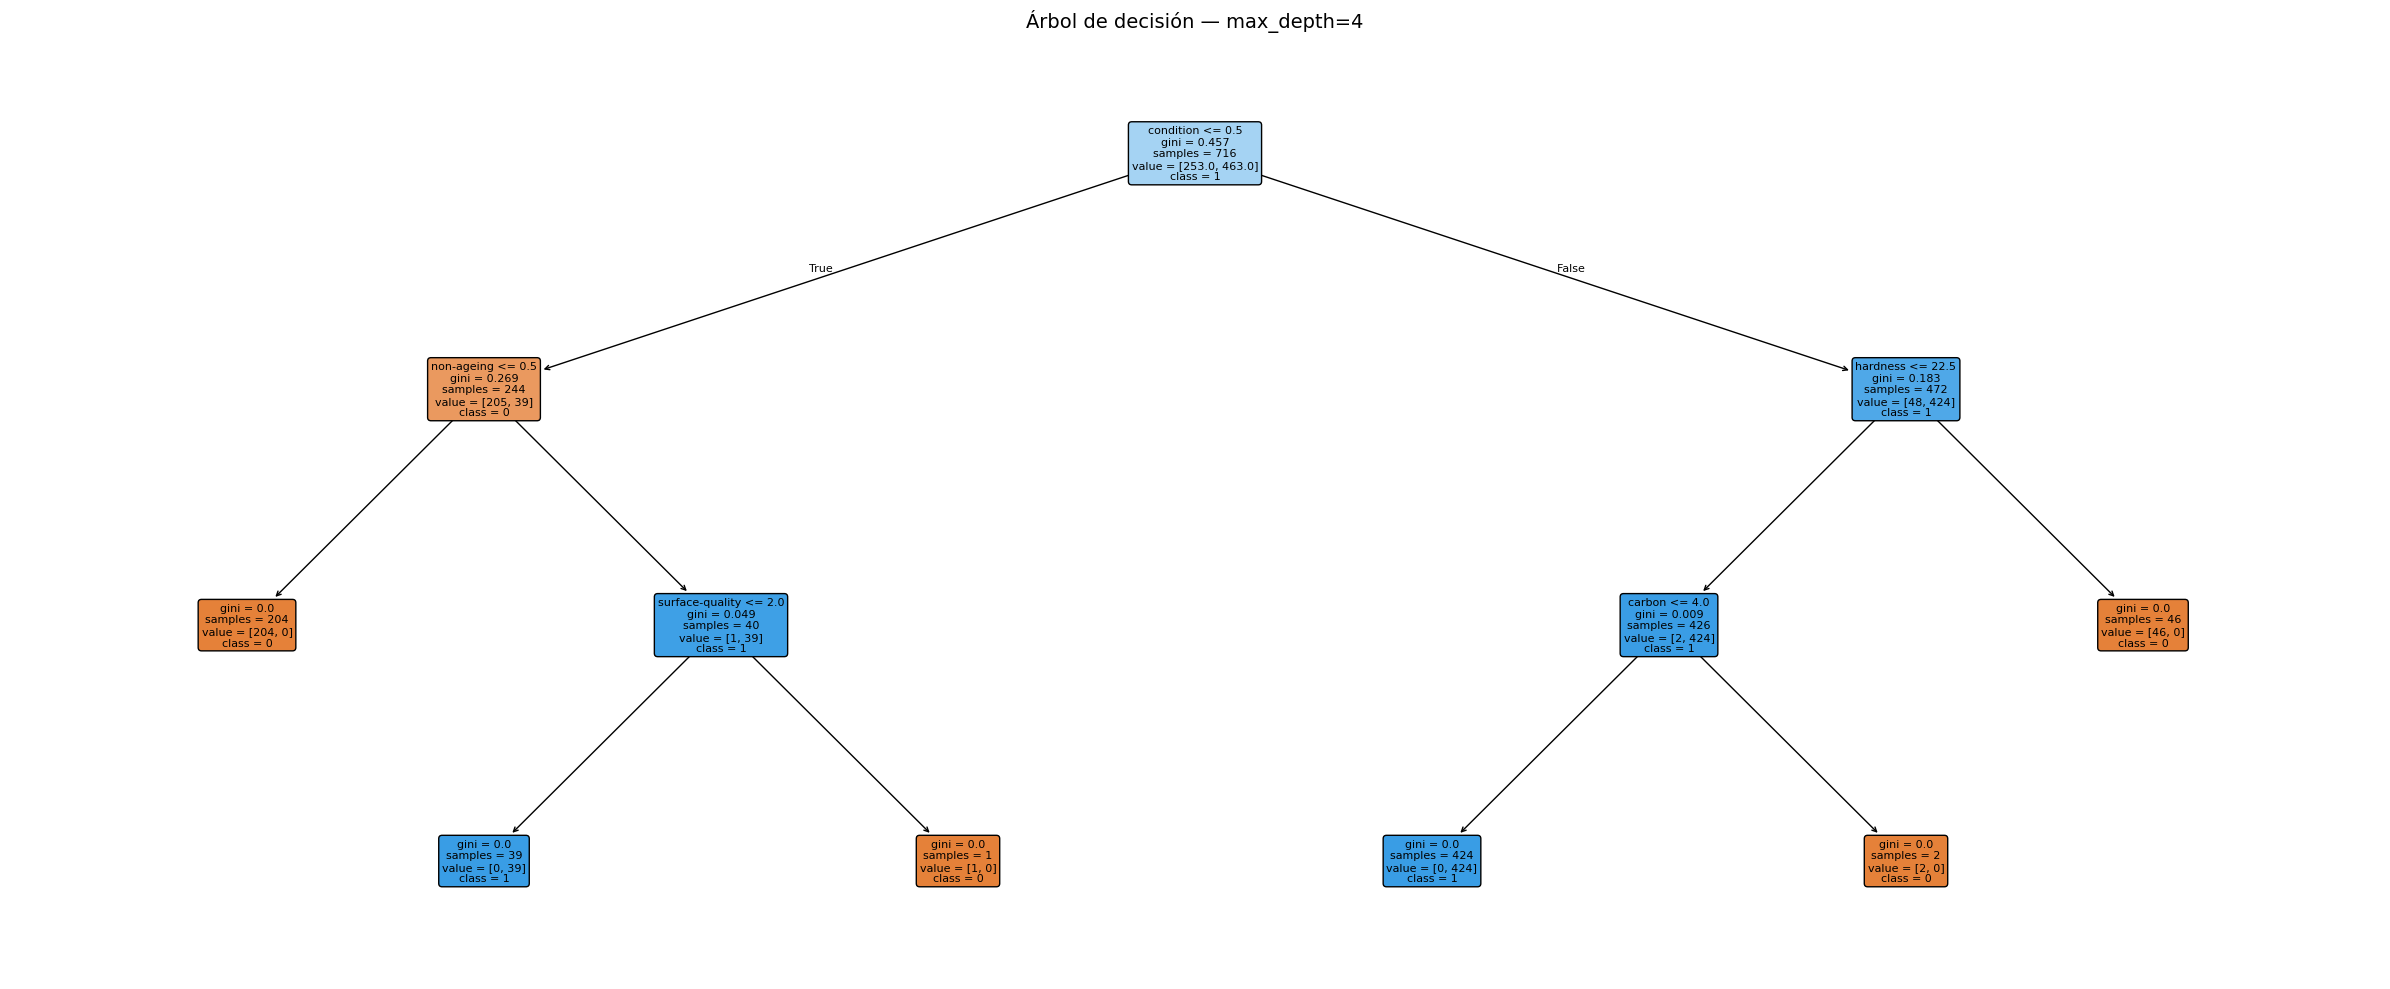

 nodo  n_instancias  precision  clase_predicha clases_reales
    2           256        1.0               0      {0: 256}
    4            46        1.0               1       {1: 46}
    5             1        1.0               0        {0: 1}
    8           534        1.0               1      {1: 534}
    9             2        1.0               0        {0: 2}
   10            57        1.0               0       {0: 57}


C:\Users\encis\AppData\Local\Temp\ipykernel_12736\4190709133.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  precision_por_hoja = df_hojas.groupby('nodo').apply(


In [21]:
## ÁRBOL PARA formability
df_tree_formability = df_tree.copy()

df_tree_formability['formability'] = np.where(df['formability'] == '?', 0, 1)


## PREPROCESADO
# Separar features y target
X = df_tree_formability.drop(columns=['formability'])
y = df_tree_formability['formability']

# Transformar columnas categóricas 
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype(str)  

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = encoder.fit_transform(X[cat_cols])


## ENTRENAMIENTO
# Conjuntos train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)

# Entrenar árbol con profundidad máxima 4
clf = DecisionTreeClassifier(max_depth=4, random_state=2026)
clf.fit(X_train, y_train)

# Evaluar
y_pred = clf.predict(X)
print(classification_report(y, y_pred))


## VISUALIZACIÓN ÁRBOL
plt.figure(figsize=(24, 10))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=clf.classes_.astype(str).tolist(),
    filled=True,       # colorea según clase mayoritaria
    rounded=True,
    impurity=True,     # muestra gini de cada nodo
    proportion=False,  # muestra conteos absolutos (no proporciones)
    fontsize=8
)
plt.title('Árbol de decisión — max_depth=4', fontsize=14)
plt.tight_layout()
plt.show()


## RENDIMIENTOS NODOS
# Obtener el nodo hoja al que va cada instancia de TEST
nodo_por_instancia = clf.apply(X)

# Construir DataFrame con: nodo asignado, clase real, clase predicha
df_hojas = pd.DataFrame({
    'nodo': nodo_por_instancia,
    'real': y.values,
    'predicho': y_pred
})

# Calcular precisión por nodo hoja
precision_por_hoja = df_hojas.groupby('nodo').apply(
    lambda g: pd.Series({
        'n_instancias': len(g),
        'precision': (g['real'] == g['predicho']).mean().round(3),
        'clase_predicha': g['predicho'].mode()[0],
        'clases_reales': dict(g['real'].value_counts())
    })
).reset_index()

precision_por_hoja = precision_por_hoja.sort_values('precision', ascending=False)
print(precision_por_hoja.to_string(index=False))

Para este atributo se logra el 100% en todo el conjunto, luego todos los '?' se reemplazan simplemente por 'No aplicable'

In [22]:
df['formability'].replace('?', "No aplicable", inplace=True)

C:\Users\encis\AppData\Local\Temp\ipykernel_12736\3120902396.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['formability'].replace('?', "No aplicable", inplace=True)


In [23]:
df['formability'][50:100]

50               1
51               2
52    No aplicable
53               2
54               2
55               2
56    No aplicable
57               2
58               5
59               5
60               3
61    No aplicable
62    No aplicable
63               2
64               1
65               3
66               3
67               2
68               3
69    No aplicable
70               2
71               1
72               2
73    No aplicable
74               3
75    No aplicable
76               3
77    No aplicable
78               2
79    No aplicable
80               2
81               2
82    No aplicable
83               3
84    No aplicable
85               3
86               2
87    No aplicable
88               1
89    No aplicable
90               1
91               2
92               2
93    No aplicable
94    No aplicable
95               3
96               3
97               3
98               2
99               2
Name: formability, dtype: object

Este atributo va a ser el último que apliquemos este filtrado para distinguir ausente y no aplicable. Debido a que el resto de atributos presentan un alto número de '?' (más de un 3/4 de los datos), y el resultado podría no ser fiable.

In [24]:
df[:10]

,family,product-type,steel,carbon,hardness,temper_rolling,condition,formability,strength,non-ageing,...,s,p,shape,thick,width,len,oil,bore,packing,class
0,?,C,R,0,0,?,S,2,0,?,...,?,?,COIL,3.200,610.0,0,?,0,?,3
1,?,C,R,0,0,?,S,2,0,?,...,?,?,SHEET,0.700,1300.0,762,?,0,?,3
2,?,C,A,0,60,T,No aplicable,No aplicable,0,?,...,?,?,COIL,2.801,385.1,0,?,0,?,3
3,?,C,A,0,60,T,No aplicable,No aplicable,0,?,...,?,?,SHEET,0.801,255.0,269,?,0,?,3
4,?,C,A,0,45,?,S,No aplicable,0,?,...,?,?,COIL,1.600,610.0,0,?,0,?,3
5,?,C,R,0,0,?,S,2,0,?,...,?,?,SHEET,0.699,610.0,4880,Y,0,?,3
6,?,C,A,0,0,?,S,2,0,?,...,?,?,COIL,3.300,152.0,0,?,0,?,3
7,?,C,R,0,0,?,S,2,0,?,...,?,?,COIL,0.699,1320.0,0,?,0,?,3
8,?,C,A,0,0,?,S,3,0,N,...,?,?,SHEET,1.000,1320.0,762,?,0,?,3
9,?,C,R,0,0,?,S,2,0,?,...,?,?,COIL,1.200,610.0,0,?,0,?,3


In [25]:
df.replace('?', np.nan , inplace=True)
df[:10]

C:\Users\encis\AppData\Local\Temp\ipykernel_12736\1466201775.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('?', np.nan , inplace=True)


,family,product-type,steel,carbon,hardness,temper_rolling,condition,formability,strength,non-ageing,...,s,p,shape,thick,width,len,oil,bore,packing,class
0,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,COIL,3.200,610.0,0,NaN,0,NaN,3
1,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,SHEET,0.700,1300.0,762,NaN,0,NaN,3
2,NaN,C,A,0,60,T,No aplicable,No aplicable,0,NaN,...,NaN,NaN,COIL,2.801,385.1,0,NaN,0,NaN,3
3,NaN,C,A,0,60,T,No aplicable,No aplicable,0,NaN,...,NaN,NaN,SHEET,0.801,255.0,269,NaN,0,NaN,3
4,NaN,C,A,0,45,NaN,S,No aplicable,0,NaN,...,NaN,NaN,COIL,1.600,610.0,0,NaN,0,NaN,3
5,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,SHEET,0.699,610.0,4880,Y,0,NaN,3
6,NaN,C,A,0,0,NaN,S,2,0,NaN,...,NaN,NaN,COIL,3.300,152.0,0,NaN,0,NaN,3
7,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,COIL,0.699,1320.0,0,NaN,0,NaN,3
8,NaN,C,A,0,0,NaN,S,3,0,N,...,NaN,NaN,SHEET,1.000,1320.0,762,NaN,0,NaN,3
9,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,COIL,1.200,610.0,0,NaN,0,NaN,3


### Ingeniería de características

Procedemos a eliminar los atributos con menos de un 5% de valores no nulos (se podría intentar analizar uno por uno por si se pudises aprovechar de alguna forma mejor)

In [26]:
datos, atributos = np.shape(df)

In [27]:
columnas_menos_95 = df.columns[df.isna().sum() > datos * 0.95]
print(columnas_menos_95)

Index(['surface-finish', 'enamelability', 'bc', 'm', 'chrom', 'phos', 'marvi',
       'exptl', 'ferro', 'corr', 'blue/bright/varn/clean', 'jurofm', 's', 'p',
       'packing'],
      dtype='object')


In [28]:
len(columnas_menos_95)

15

In [29]:
columnas_mas_95 = df.columns[df.isna().sum() < datos * 0.95]
print(columnas_mas_95)

Index(['family', 'product-type', 'steel', 'carbon', 'hardness',
       'temper_rolling', 'condition', 'formability', 'strength', 'non-ageing',
       'surface-quality', 'bf', 'bt', 'bw/me', 'bl', 'cbond', 'lustre',
       'shape', 'thick', 'width', 'len', 'oil', 'bore', 'class'],
      dtype='object')


In [30]:
len(columnas_mas_95)

24

In [31]:
df = df.drop(columns=columnas_menos_95)

df.head()

,family,product-type,steel,carbon,hardness,temper_rolling,condition,formability,strength,non-ageing,...,bl,cbond,lustre,shape,thick,width,len,oil,bore,class
0,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,Y,COIL,3.200,610.0,0,NaN,0,3
1,NaN,C,R,0,0,NaN,S,2,0,NaN,...,NaN,NaN,NaN,SHEET,0.700,1300.0,762,NaN,0,3
2,NaN,C,A,0,60,T,No aplicable,No aplicable,0,NaN,...,NaN,NaN,NaN,COIL,2.801,385.1,0,NaN,0,3
3,NaN,C,A,0,60,T,No aplicable,No aplicable,0,NaN,...,Y,Y,NaN,SHEET,0.801,255.0,269,NaN,0,3
4,NaN,C,A,0,45,NaN,S,No aplicable,0,NaN,...,NaN,NaN,NaN,COIL,1.600,610.0,0,NaN,0,3


Matriz de correlación de Pearson

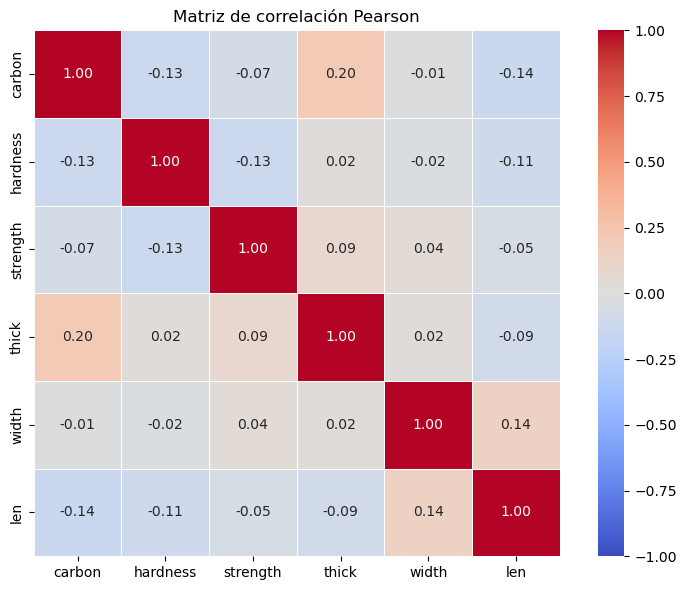

In [32]:
import seaborn as sns

# Las columnas continuas del dataset
numeric_cols = ['carbon', 'hardness', 'strength', 'thick', 'width', 'len']

df_numerica = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

corr_matrix = df_numerica.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # muestra el valor numérico en cada celda
    fmt='.2f',           # 2 decimales
    cmap='coolwarm',     # azul=negativa, rojo=positiva
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Matriz de correlación Pearson')
plt.tight_layout()
plt.show()

Observamos que no hay ninguna correlación fuerte, por lo que mantenemos todas las variables continuas por ahora.

Para terminar analizaremos la distribución de valores de cada atributo

In [33]:
for atributo in df.columns:
    print(f"Atributo {atributo}:\n")
    print(df[atributo].value_counts()/datos)

Atributo family:

family
TN    0.074777
ZS    0.065848
Name: count, dtype: float64
Atributo product-type:

product-type
C    1.0
Name: count, dtype: float64
Atributo steel:

steel
A               0.488839
R               0.285714
No aplicable    0.062500
K               0.056920
M               0.022321
W               0.021205
V               0.017857
S               0.011161
Name: count, dtype: float64
Atributo carbon:

carbon
0     0.915179
55    0.021205
45    0.018973
65    0.016741
6     0.012277
70    0.005580
4     0.004464
10    0.002232
8     0.002232
3     0.001116
Name: count, dtype: float64
Atributo hardness:

hardness
0     0.803571
45    0.063616
85    0.039062
50    0.037946
60    0.029018
70    0.021205
80    0.005580
Name: count, dtype: float64
Atributo temper_rolling:

temper_rolling
T    0.152902
Name: count, dtype: float64
Atributo condition:

condition
S               0.617188
No aplicable    0.146205
A               0.044643
Name: count, dtype: float64
Atributo f

Observamos que hay atributos con gran desbalance. Vamos a quitar los siguientes atributos:
* 'lustre' contiene casi 95% (0.94308) de datos NaN 
* product-type el 100% de los datos pertenecen a la misma categoria, atributo irrelevante.

In [34]:
df = df.drop(columns=['lustre','product-type'])

In [35]:
df.head()

,family,steel,carbon,hardness,temper_rolling,condition,formability,strength,non-ageing,surface-quality,...,bw/me,bl,cbond,shape,thick,width,len,oil,bore,class
0,NaN,R,0,0,NaN,S,2,0,NaN,E,...,NaN,NaN,NaN,COIL,3.200,610.0,0,NaN,0,3
1,NaN,R,0,0,NaN,S,2,0,NaN,E,...,B,NaN,NaN,SHEET,0.700,1300.0,762,NaN,0,3
2,NaN,A,0,60,T,No aplicable,No aplicable,0,NaN,G,...,M,NaN,NaN,COIL,2.801,385.1,0,NaN,0,3
3,NaN,A,0,60,T,No aplicable,No aplicable,0,NaN,G,...,B,Y,Y,SHEET,0.801,255.0,269,NaN,0,3
4,NaN,A,0,45,NaN,S,No aplicable,0,NaN,D,...,NaN,NaN,NaN,COIL,1.600,610.0,0,NaN,0,3


### Preprocesamiento de los datos

Vamos a tratar con los datos para dejarlos listos para aplicarlos a los modelos. Para ello el orden de trabajo a seguir es:
* Vamos a transformar primero todos los valores no nulo.
* Normalizaremos todos los datos y asignaremos valores a datos nulos

Atributos que toman solo 2 valores distintos sin contar NaN, transformación binaria (y posteriormente imputación de valores NaN):
* family
* bw/me
* shape
* oil

Atributos que toman solo 2 valores distintos contando NaN, transformación binaria:
* temper_rolling
* non-ageing
* bf
* bt
* bl
* cbond

Atributos que toman más de 2 valores y no presentan un orden implicito, transformación one-hot:
* steel
* condition
* surface-quality

Atributos que presentan un orden implicito, transformación ordenaria:
* formability

In [36]:
columnas_binarias = [
    'family',
    'bw/me',
    'shape',
    'oil'
]

columnas_binarias_NaN = [
    'temper_rolling',
    'non-ageing',
    'bf',
    'bt',
    'bl',
    'cbond'
]

columnas_one_hot = ['steel', 'condition', 'surface-quality']

columnas_ordinal = ['formability']

In [37]:
from sklearn.preprocessing import LabelBinarizer

# Version binaria codificar NaN
lb_sin_nan = LabelBinarizer()
for col in columnas_binarias_NaN:
    df[col] = lb_sin_nan.fit_transform(df[col].astype(str))

# Version binaria sin codificar NaN
lb_con_nan = LabelBinarizer()
for col in columnas_binarias:
    mask_nan = df[col].isna()  # guardar posición de NaN
    df[col] = lb_con_nan.fit_transform(df[col].fillna('__nan__').astype(str))
    df.loc[mask_nan, col] = np.nan  # restaurar NaN

Para el one-hot vamos a distinguir por un lado 'no aplicable' de 'NaN'

In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


one_hot = OneHotEncoder(sparse_output=False)

ct = ColumnTransformer(transformers=[('ohe', one_hot, columnas_one_hot)],remainder='passthrough')# passthrough para que el resto de columnas se queden como están

ct.set_output(transform='pandas')
df = ct.fit_transform(df)

Resulta que con la transformación, ahora tenemos nuevos nombres para nuestros atributos.

In [39]:
df.head()

,ohe__steel_A,ohe__steel_K,ohe__steel_M,ohe__steel_No aplicable,ohe__steel_R,ohe__steel_S,ohe__steel_V,ohe__steel_W,ohe__steel_nan,ohe__condition_A,...,remainder__bw/me,remainder__bl,remainder__cbond,remainder__shape,remainder__thick,remainder__width,remainder__len,remainder__oil,remainder__bore,remainder__class
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,1,0.0,3.200,610.0,0,NaN,0,3
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1,1,1.0,0.700,1300.0,762,NaN,0,3
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,1,0.0,2.801,385.1,0,NaN,0,3
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0,0,1.0,0.801,255.0,269,NaN,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,1,0.0,1.600,610.0,0,NaN,0,3


Vamos a recuperar nuestos nombres para los atributos que no se han transformado one-hot

In [40]:
df.columns = [col.replace('remainder__', '') for col in df.columns]

df.head()

,ohe__steel_A,ohe__steel_K,ohe__steel_M,ohe__steel_No aplicable,ohe__steel_R,ohe__steel_S,ohe__steel_V,ohe__steel_W,ohe__steel_nan,ohe__condition_A,...,bw/me,bl,cbond,shape,thick,width,len,oil,bore,class
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,1,0.0,3.200,610.0,0,NaN,0,3
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1,1,1.0,0.700,1300.0,762,NaN,0,3
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,1,0.0,2.801,385.1,0,NaN,0,3
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0,0,1.0,0.801,255.0,269,NaN,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,1,0.0,1.600,610.0,0,NaN,0,3


Resulta que 'formability' ya está en orden, pero nos queda asignar el valor 'No aplicable' al valor $0$.

In [41]:
df[columnas_ordinal] = df[columnas_ordinal].replace('No aplicable', 0)

Ya tenemos todas nuestras columnas expresadas en valores numéricos (menos por los valores nulos y clase objetivo).

In [42]:
df.head()

,ohe__steel_A,ohe__steel_K,ohe__steel_M,ohe__steel_No aplicable,ohe__steel_R,ohe__steel_S,ohe__steel_V,ohe__steel_W,ohe__steel_nan,ohe__condition_A,...,bw/me,bl,cbond,shape,thick,width,len,oil,bore,class
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,1,0.0,3.200,610.0,0,NaN,0,3
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1,1,1.0,0.700,1300.0,762,NaN,0,3
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,1,0.0,2.801,385.1,0,NaN,0,3
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0,0,1.0,0.801,255.0,269,NaN,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1,1,0.0,1.600,610.0,0,NaN,0,3


Vamos a transformar los valores NaN de las columnas resultantes (vamos a suponer que aunque los atributos numéricos tengan muchos $0$ esto no equivale a valores 'NaN', aunque resulta llamativo que los atributos continuos no presenten valores nulos).

Para imputar valores sobre los atributos que quedan con valores NaN, vamos a usar 'IterativeImputer' de scikit learn, para entrenar un modelo a predecir los valores NaN a partir del resto de columnas.


In [43]:
# Import obligatorio para desbloquear el experimental
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge


# Usamos BayesianRidge predecir valores NaN de cada columna
imputer = IterativeImputer(
    estimator=BayesianRidge(),  # modelo que predice cada columna con NaN
    max_iter=10,                # iteraciones del ciclo de imputación
    random_state=2026
)

# Fit y transform solo sobre las columnas binarias
df[columnas_binarias] = imputer.fit_transform(df[columnas_binarias])

# Redondear a 0 o 1
df[columnas_binarias] = df[columnas_binarias].round().astype(int)

Veamos que ya tenemos todos nuestros datos sin valores nulos y en numérico.

In [44]:
df.head()

,ohe__steel_A,ohe__steel_K,ohe__steel_M,ohe__steel_No aplicable,ohe__steel_R,ohe__steel_S,ohe__steel_V,ohe__steel_W,ohe__steel_nan,ohe__condition_A,...,bw/me,bl,cbond,shape,thick,width,len,oil,bore,class
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,0,3.200,610.0,0,0,0,3
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1,1,1,1,0.700,1300.0,762,0,0,3
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,0,2.801,385.1,0,0,0,3
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0.801,255.0,269,0,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,0,1.600,610.0,0,0,0,3


In [45]:
for atributo in df.columns:
    print(f"Atributo {atributo}:\n")
    print(df[atributo].value_counts()/datos)

Atributo ohe__steel_A:

ohe__steel_A
0.0    0.511161
1.0    0.488839
Name: count, dtype: float64
Atributo ohe__steel_K:

ohe__steel_K
0.0    0.94308
1.0    0.05692
Name: count, dtype: float64
Atributo ohe__steel_M:

ohe__steel_M
0.0    0.977679
1.0    0.022321
Name: count, dtype: float64
Atributo ohe__steel_No aplicable:

ohe__steel_No aplicable
0.0    0.9375
1.0    0.0625
Name: count, dtype: float64
Atributo ohe__steel_R:

ohe__steel_R
0.0    0.714286
1.0    0.285714
Name: count, dtype: float64
Atributo ohe__steel_S:

ohe__steel_S
0.0    0.988839
1.0    0.011161
Name: count, dtype: float64
Atributo ohe__steel_V:

ohe__steel_V
0.0    0.982143
1.0    0.017857
Name: count, dtype: float64
Atributo ohe__steel_W:

ohe__steel_W
0.0    0.978795
1.0    0.021205
Name: count, dtype: float64
Atributo ohe__steel_nan:

ohe__steel_nan
0.0    0.966518
1.0    0.033482
Name: count, dtype: float64
Atributo ohe__condition_A:

ohe__condition_A
0.0    0.955357
1.0    0.044643
Name: count, dtype: float64
At

Resultados de la imputación sobre valores NaN:
* **Family:** Presenta 4 cateogrías, antes eran solo 2 pero en la información se indican que hay hasta 9 posibles
* **bw/me:** Sigue presentando tan solo 2 categorías
* **shape:** Sigue presentando tan solo 2 categorías
* **oil:** Ha pasado de 2 categorías a 6, en la información se indican que hay solo 2 posibles valores. Por lo que vamos a transformarlos de nuevo mediante el umbral: 
$$x \leq 0 \Rightarrow 0 \quad \mid \quad x > 0 \Rightarrow 1$$

In [46]:
df['oil'] = np.where(df['oil'] > 0, 1, 0)

Vamos a transformar las clases a etiquetas del 0 al 4 (todas las clases corresponde con un valor menos, y la clase 'U' es la clase '4').

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])


Para terminar con el preprocesado, vamos a normalizar todos los valores (para que tengan misma distribución al aplicarlos en modelos de regresión) y separar el conjunto de datos entre entrenamiento y test.

In [48]:
from sklearn.model_selection import train_test_split


# Separamos los conjuntos en entrenamiento / test y validación
X = df.drop(columns=['class']).copy() # Atributos sin clase objetivo
y = df['class'].copy() # Clase objetivo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=2026, stratify=y_test)


In [49]:
print(f"Tamaño del conjunto de entrenamiento:{np.shape(X_train)}")
print(f"Tamaño del conjunto de test:{np.shape(X_test)}")
print(f"Tamaño del conjunto de validación:{np.shape(X_val)}")

Tamaño del conjunto de entrenamiento:(716, 37)
Tamaño del conjunto de test:(90, 37)
Tamaño del conjunto de validación:(90, 37)


Vamos a terminar el preprocesameinto, normalizando los datos mediante la media y desviación.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.set_output(transform='pandas') # Mantener dataframe
X_train = scaler.fit_transform(X_train) # Aplicar fit y transform sobre conjunto de entrenamiento
X_val  = scaler.transform(X_val) # Aplicar transform sobre conjunto de validacion
X_test = scaler.transform(X_test) # Aplicar transform sobre conjunto de test

In [51]:
print(X_train.mean().round(3))
print(X_train.std().round(3))

print(X_test.mean().round(3))
print(X_test.std().round(3))

ohe__steel_A                         0.0
ohe__steel_K                         0.0
ohe__steel_M                         0.0
ohe__steel_No aplicable              0.0
ohe__steel_R                        -0.0
ohe__steel_S                        -0.0
ohe__steel_V                         0.0
ohe__steel_W                         0.0
ohe__steel_nan                       0.0
ohe__condition_A                     0.0
ohe__condition_No aplicable         -0.0
ohe__condition_S                    -0.0
ohe__condition_nan                  -0.0
ohe__surface-quality_D               0.0
ohe__surface-quality_E              -0.0
ohe__surface-quality_F              -0.0
ohe__surface-quality_G              -0.0
ohe__surface-quality_No aplicable    0.0
ohe__surface-quality_nan             0.0
family                               0.0
carbon                               0.0
hardness                             0.0
temper_rolling                      -0.0
formability                          0.0
strength        

### Mejora iterativa de modelos

Vamos a probar 3 modelos, de familias diferentes, con la idea de aplicar luego un sistema de votación para obtener un mayor rendimiento. Los tres modelos serán:
* Random Forest
* Regresión logística
* Perceptrón multicapa

In [52]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Random forest
RF  = RandomForestClassifier(
          n_estimators=100,
          class_weight='balanced',
          random_state=2026
      )

# Regresión logística
RL  = LogisticRegression(
          max_iter=1000,
          class_weight='balanced',
          random_state=2026
      )

# Perceptrón multicapa
PMC = MLPClassifier(
          hidden_layer_sizes=(64, 32, 16), # 3 Capas con 64, 32 y 16 neuronas respectivamente 
          max_iter=500,
          random_state=2026
      )

votacion = VotingClassifier(
    estimators=[
        ('Random Forest',  RF),
        ('Regresion Logistica',  RL),
        ('Perceptron', PMC)
    ],
    voting='soft', # Votación mediante ponderación de probabilidades
    weights=[1, 1, 1] # Empezamos asignando mismo peso a cada modelo
)

Entrenamos cada modelo y evaluamos el rendimiento sobre conjunto de test.

In [53]:
# Entrenar cada modelo
RF.fit(X_train, y_train)
RL.fit(X_train, y_train)
PMC.fit(X_train, y_train)
votacion.fit(X_train, y_train)

# Evaluar cada modelo
y_pred_RF = RF.predict(X_test)
print("Rendimiento Random Forest")
print(classification_report(y_test, y_pred_RF))

y_pred_RL = RL.predict(X_test)
print("Rendimiento Regresión Logística")
print(classification_report(y_test, y_pred_RL))

y_pred_PMC = PMC.predict(X_test)
print("Rendimiento Perceptrón")
print(classification_report(y_test, y_pred_PMC))

y_pred_votacion = votacion.predict(X_test)
print("Rendimiento Sistema de votación")
print(classification_report(y_test, y_pred_votacion))

Rendimiento Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.91      1.00      0.95        10
           2       1.00      0.99      0.99        69
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00         4

    accuracy                           0.99        90
   macro avg       0.98      1.00      0.99        90
weighted avg       0.99      0.99      0.99        90

Rendimiento Regresión Logística
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.91      1.00      0.95        10
           2       1.00      0.94      0.97        69
           3       1.00      1.00      1.00         6
           4       0.57      1.00      0.73         4

    accuracy                           0.96        90
   macro avg       0.90      0.99      0.93        90
weighted avg       

In [54]:
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import numpy as np

print("y_train unique:", sorted(y_train.unique()))
print("y_train dtype:", y_train.dtype)

# Comprobar que esto, aislado, NO da error
clases = np.unique(y_train)
cw = compute_class_weight('balanced', classes=clases, y=y_train)
cw_dict = dict(zip(clases, cw))
print("class_weight dict:", cw_dict)

# Si esto da error, ya sabemos que el problema viene de aquí
sw = compute_sample_weight(cw_dict, y_train)

y_train unique: [0, 1, 2, 3, 4]
y_train dtype: int32
class_weight dict: {0: 23.866666666666667, 1: 1.8126582278481012, 2: 0.26275229357798163, 3: 2.651851851851852, 4: 4.475}


Como estamos tratando con clases desbalanceadas (la clase 1 tiene $1$ instancia vs la clase 3 que tiene $69$ instancias), vamos a fijarnos sobretodo en los resultados F1-score antes que precision. Observamos que los rendimientos son bastante buenos en general. 

* Random Forest: Tan solo falla en las clases 1,2 pero con un rendimiento de f1 del 95% y 99% respectivamente (que además corresponden con las clases más pobladas). De media ponderada obtiene f1-score -> 99% 
* Regresión Logística: Un poco peor que RF, fallando también en la clase U con un rendimiento regular con menos del 75%. De media ponderada obtiene f1-score -> 96% 
* Perceptrón multicapa: Sorprendentemente logra el 100% en todo por lo que de media ponderada obtiene f1-score -> 100% 
* Sistema de votación: Rendimiento identico que RF.

##### Reducción de dimensionalidad mediante PCA

In [55]:
from sklearn.decomposition import PCA

# Vamos a ver, para distintos valores de varianza acumulada, cuanto consigue reducir la dimensionalidad
for var in [0.50,0.60,0.70,0.80,0.90,0.95]:
    print(f"PCA para alcanzar {var*100}% de varianza:")
    pca = PCA(n_components=var)  

    # fit en train, transform en train y test
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    print(f"\nDimensión original:  {X_train.shape[1]}")
    print(f"\nDimensión reducida:  {X_train_pca.shape[1]}")
    print(f"\nVarianza presente:  {pca.explained_variance_ratio_.sum():.3f}")
    print("\n")

PCA para alcanzar 50.0% de varianza:

Dimensión original:  37

Dimensión reducida:  6

Varianza presente:  0.511


PCA para alcanzar 60.0% de varianza:

Dimensión original:  37

Dimensión reducida:  9

Varianza presente:  0.630


PCA para alcanzar 70.0% de varianza:

Dimensión original:  37

Dimensión reducida:  11

Varianza presente:  0.701


PCA para alcanzar 80.0% de varianza:

Dimensión original:  37

Dimensión reducida:  15

Varianza presente:  0.814


PCA para alcanzar 90.0% de varianza:

Dimensión original:  37

Dimensión reducida:  20

Varianza presente:  0.908


PCA para alcanzar 95.0% de varianza:

Dimensión original:  37

Dimensión reducida:  23

Varianza presente:  0.951




##### Selección de características

Al haber usado RL, podríamos haber aplicado penalización Lasso para medir importancia a la vez que entrenamos el modelo, pero he considerado más interesante usar la técnica de permutación de característica para medir la importancia de cada atributo: 

Partiendo del rendimiento del PMC con valor 100%, analizaremos cuanto rendimiento se pierde al permutar las instancias para una columna en concreto (suponiendo que no hay correlación entre atributos). 

In [56]:
from sklearn.inspection import permutation_importance

# Para cada columna repetimos 10 veces el proceso (para reducir aleatoriedad)
resultados_permutacion = permutation_importance(
    PMC, # Perceptron
    X_test, # evaluar sobre test
    y_test,
    n_repeats=10, # número de veces que repetimos proceso por cada columna
    random_state=2026,
    scoring='f1_weighted' # f1 para medir variación de rendimiento
)

# Ordenar por importancia media
importancias = pd.DataFrame({
    'feature':    X_train.columns,
    'importancia': resultados_permutacion.importances_mean,
    'std':         resultados_permutacion.importances_std
}).sort_values('importancia', ascending=False)

print(importancias.head(15))

                        feature  importancia       std
18     ohe__surface-quality_nan     0.149846  0.017110
21                     hardness     0.068527  0.019592
16       ohe__surface-quality_G     0.037813  0.012366
22               temper_rolling     0.036754  0.007902
13       ohe__surface-quality_D     0.033398  0.012851
8                ohe__steel_nan     0.021338  0.009516
23                  formability     0.018671  0.012261
10  ohe__condition_No aplicable     0.018238  0.003852
12           ohe__condition_nan     0.016749  0.006366
2                  ohe__steel_M     0.014899  0.005401
24                     strength     0.014804  0.005261
35                          oil     0.014430  0.007950
0                  ohe__steel_A     0.012411  0.006156
31                        shape     0.011521  0.007199
30                        cbond     0.010433  0.012169


Observamos que la característica más importante es si **surface-quality** es NaN o no (podríamos estudiar en más profundidad si se debe porque debería ser 'No aplicable' en vez de un valor nulo). El segundo atributo más relevante es **hardness**, lo cual tiene sentido aunque su importancia es menor a la mitad. Destacar que del filtrado que al principio, entre **NaN** y **no aplicable**, se ha obtenido que **```ohe__condition_No aplicable```** resulta ser importante para la clasificación.

##### Reducción de atributos

Como la técnica de importancia de atributos anterior, revelo que ```ohe__surface-quality_nan, hardness``` corresponden con los 2 atributos más influyentes para la toma de decisiones. Vamos a medir el rendimiento de los modelos usando tan solo las mediciones en estos atributos.

In [57]:
df_simple = df[['ohe__surface-quality_nan','hardness','class']].copy()
df_simple.head()

,ohe__surface-quality_nan,hardness,class
0,0.0,0,2
1,0.0,0,2
2,0.0,60,2
3,0.0,60,2
4,0.0,45,2


Repetimos el proceso de generar conjuntos de train/test.

In [58]:
# Separamos los conjuntos en entrenamiento / test y validación
X_2 = df_simple.drop(columns=['class']).copy() # Atributos sin clase objetivo
y_2 = df_simple['class'].copy() # Clase objetivo
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=2026, stratify=y_2)
X_test_2, X_val_2, y_test_2, y_val_2 = train_test_split(X_test_2, y_test_2, test_size=0.5, random_state=2026, stratify=y_test_2)

print(f"Tamaño del conjunto de entrenamiento:{np.shape(X_train_2)}")
print(f"Tamaño del conjunto de test:{np.shape(X_test_2)}")
print(f"Tamaño del conjunto de validación:{np.shape(X_val_2)}")


Tamaño del conjunto de entrenamiento:(716, 2)
Tamaño del conjunto de test:(90, 2)
Tamaño del conjunto de validación:(90, 2)


Normalizamos mediante conjunto de entrenamiento.

In [59]:
scaler.set_output(transform='pandas') # Mantener dataframe
X_train_2 = scaler.fit_transform(X_train_2) # Aplicar fit y transform sobre conjunto de entrenamiento
X_val_2  = scaler.transform(X_val_2) # Aplicar transform sobre conjunto de validacion
X_test_2 = scaler.transform(X_test_2) # Aplicar transform sobre conjunto de test

In [60]:
print(X_train_2.mean().round(3))
print(X_train_2.std().round(3))

print(X_test_2.mean().round(3))
print(X_test_2.std().round(3))

ohe__surface-quality_nan    0.0
hardness                    0.0
dtype: float64
ohe__surface-quality_nan    1.001
hardness                    1.001
dtype: float64
ohe__surface-quality_nan    0.030
hardness                    0.058
dtype: float64
ohe__surface-quality_nan    1.037
hardness                    1.059
dtype: float64


Modelos de aprendizaje

In [61]:
# Random forest
RF_2  = RandomForestClassifier(
          n_estimators=100,
          class_weight='balanced',
          random_state=2026
      )

# Regresión logística
RL_2  = LogisticRegression(
          max_iter=1000,
          class_weight='balanced',
          random_state=2026
      )

# Perceptrón multicapa
PMC_2 = MLPClassifier(
          hidden_layer_sizes=(64, 32, 16), # 3 Capas con 64, 32 y 16 neuronas respectivamente 
          max_iter=500,
          random_state=2026
      )

votacion_2 = VotingClassifier(
    estimators=[
        ('Random Forest',  RF_2),
        ('Regresion Logistica',  RL_2),
        ('Perceptron', PMC_2)
    ],
    voting='soft', # Votación mediante ponderación de probabilidades
    weights=[1, 1, 1] # Empezamos asignando mismo peso a cada modelo
)

Entrenamiento y rendimiento

In [62]:
# Entrenar cada modelo
votacion_2.fit(X_train_2, y_train_2)
RF_2.fit(X_train_2, y_train_2)
RL_2.fit(X_train_2, y_train_2)
PMC_2.fit(X_train_2, y_train_2)

# Evaluar cada modelo
y_pred_RF = RF_2.predict(X_test_2)
print("Rendimiento Random Forest")
print(classification_report(y_test_2, y_pred_RF))

y_pred_RL = RL_2.predict(X_test_2)
print("Rendimiento Regresión Logística")
print(classification_report(y_test_2, y_pred_RL))

y_pred_PMC = PMC_2.predict(X_test_2)
print("Rendimiento Perceptrón")
print(classification_report(y_test_2, y_pred_PMC))

y_pred_votacion = votacion_2.predict(X_test_2)
print("Rendimiento Sistema de votación")
print(classification_report(y_test_2, y_pred_votacion))

Rendimiento Random Forest
              precision    recall  f1-score   support

           0       0.08      1.00      0.14         1
           1       0.00      0.00      0.00        10
           2       1.00      0.22      0.36        69
           3       0.09      0.83      0.16         6
           4       1.00      1.00      1.00         4

    accuracy                           0.28        90
   macro avg       0.43      0.61      0.33        90
weighted avg       0.82      0.28      0.33        90

Rendimiento Regresión Logística
              precision    recall  f1-score   support

           0       0.08      1.00      0.14         1
           1       0.00      0.00      0.00        10
           2       0.91      0.86      0.88        69
           3       0.00      0.00      0.00         6
           4       0.33      1.00      0.50         4

    accuracy                           0.71        90
   macro avg       0.26      0.57      0.30        90
weighted avg       

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\encis\anaconda3\Lib

Hemos logrado reducir el rendimiento al usar únicamente 2 atributos para la predicción

* Random Forest: Falla en la predicción de clase 0,1,2,3. De media ponderada obtiene f1-score -> 33% 
* Regresión Logística: Falla en la predicción de clase 0,1,3,4. De media ponderada obtiene f1-score -> 70% (aunque media aritmética solo logra 30%) 
* Perceptrón multicapa: Falla en la predicción de clase 0,3. De media ponderada obtiene f1-score -> 85% (aunque media aritmética solo logra 55%) 
* Sistema de votación: Rendimiento identico que PMC.

##### Ajuste de hiperparámetros

En esta sección vamos a añadir dificultad a los modelos para poder analizar en mayor medida el rendimiento obtenido despues de obtimizar los hiperparámetros. Para ello, podríamos aplicar dos enfoques:
* Quedarnos únicamente con un número muy reducido de características más influyentes.
* Eliminar las características más influyentes, y quedarnos con las peores.

Vamos a decantarnos por la primera opción por varios motivos:
* Al quedarnos con menos atributos, estamos reduciendo la dimensionalidad y mejora el coste computacional de los modelos
* Es más fácil obtener una representación de los datos en $\mathbb{R}^2$ o $\mathbb{R}^3$, lo cual nos facilita la interpretación de los modelos. 

In [63]:
import plotly.express as px

df_train = pd.concat([X_train_2, y_train_2], axis=1)

# Colores distintos apra cada clase
COLOR_MAP = {
    '1': '#1f77b4',   # azul
    '2': '#ff7f0e',   # naranja
    '3': '#2ca02c',   # verde
    '4': '#d62728',   # rojo
    '5': '#9467bd',   # morado
    'U': '#8c564b',   # marrón
}

# Formas distintas para cada clase
SYMBOL_MAP = {
    '1': 'circle',
    '2': 'square',
    '3': 'diamond',
    '4': 'cross',
    '5': 'x',
    'U': 'triangle-up'
}

fig = px.scatter(
    df_train,
    x='hardness',
    y='ohe__surface-quality_nan',
    color='class',
    color_discrete_map=COLOR_MAP,
    symbol='class',         
    symbol_map=SYMBOL_MAP, 
    title='Distribución de instancias por clase entrenamiento',
    labels={'class': 'Clase'}
)
fig.show()

df_test = pd.concat([X_test_2, y_test_2], axis=1)

fig = px.scatter(
    df_test,
    x='hardness',    
    y='ohe__surface-quality_nan',
    color='class',
    color_discrete_map=COLOR_MAP,
    symbol='class',         
    symbol_map=SYMBOL_MAP,
    title='Distribución de instancias por clase test',
    labels={'class': 'Clase'}
)
fig.show()

df_val = pd.concat([X_val_2, y_val_2], axis=1)

fig = px.scatter(
    df_val,
    x='hardness',
    y='ohe__surface-quality_nan',
    color='class',
    color_discrete_map=COLOR_MAP,
    symbol='class',         
    symbol_map=SYMBOL_MAP,
    title='Distribución de instancias por clase validacion',
    labels={'class': 'Clase'}
)
fig.show()

Observamos que para datos con ```hardness``` por encima de 0, es fácilmente clasificable cada instancias (porque no se solapan). El inconveniente son los datos que tienen ```hardness``` por debajo de 0, ya que sus coordenadas (x,y) son iguales pero con diferente clasificación, no hay forma de poder distinguirlas.

Vamos a probar a continuación el segundo enfoque de usar únicamente los peores atributos. La idea es añadir más diversidad (y de este modo poder diferenciar cada instancia), para optimizar los hiperparámetros.

Los mejores 20 atributos que vamos a descartar son:

In [64]:
importancias[:20]

,feature,importancia,std
18,ohe__surface-quality_nan,0.149846,0.017110
21,hardness,0.068527,0.019592
16,ohe__surface-quality_G,0.037813,0.012366
22,temper_rolling,0.036754,0.007902
13,ohe__surface-quality_D,0.033398,0.012851
8,ohe__steel_nan,0.021338,0.009516
23,formability,0.018671,0.012261
10,ohe__condition_No aplicable,0.018238,0.003852
12,ohe__condition_nan,0.016749,0.006366
2,ohe__steel_M,0.014899,0.005401


Vamos a quedarnos con el resto de atributos:

In [65]:
importancias[20:]

,feature,importancia,std
28,bw/me,0.005444,0.005444
9,ohe__condition_A,0.004603,0.007676
4,ohe__steel_R,0.004550,0.005582
20,carbon,0.003986,0.006225
25,non-ageing,0.003409,0.005207
26,bf,0.003160,0.004827
1,ohe__steel_K,0.002849,0.005797
15,ohe__surface-quality_F,0.002323,0.004647
5,ohe__steel_S,0.001158,0.003473
36,bore,0.001136,0.003409


Como las últimas columnas no aportan mejoría, vamos a eliminarlas también.

In [66]:
importancias[20:27]

,feature,importancia,std
28,bw/me,0.005444,0.005444
9,ohe__condition_A,0.004603,0.007676
4,ohe__steel_R,0.004550,0.005582
20,carbon,0.003986,0.006225
25,non-ageing,0.003409,0.005207
26,bf,0.003160,0.004827
1,ohe__steel_K,0.002849,0.005797


In [67]:
nuevas_columnas = importancias['feature'][20:27].tolist() + ['class']
print(nuevas_columnas)

['bw/me', 'ohe__condition_A', 'ohe__steel_R', 'carbon', 'non-ageing', 'bf', 'ohe__steel_K', 'class']


In [68]:
df_menos_relevantes = df[nuevas_columnas].copy()
df_menos_relevantes.head()

,bw/me,ohe__condition_A,ohe__steel_R,carbon,non-ageing,bf,ohe__steel_K,class
0,0,0.0,1.0,0,1,1,0.0,2
1,1,0.0,1.0,0,1,0,0.0,2
2,0,0.0,0.0,0,1,1,0.0,2
3,1,0.0,0.0,0,1,1,0.0,2
4,0,0.0,0.0,0,1,1,0.0,2


In [69]:
## Seleccionamos únicamente los datos con las columnas menos relevantes

# Separamos los conjuntos en entrenamiento / test y validación
X = df_menos_relevantes.drop(columns=['class']).copy() # Atributos sin clase objetivo
y = df_menos_relevantes['class'].copy() # Clase objetivo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=2026, stratify=y_test)

## Normalizar los datos mediante train y despues aplicarlo a test

scaler = StandardScaler()

scaler.set_output(transform='pandas') # Mantener dataframe
X_train = scaler.fit_transform(X_train) # Aplicar fit y transform sobre conjunto de entrenamiento
X_val  = scaler.transform(X_val) # Aplicar transform sobre conjunto de validacion
X_test = scaler.transform(X_test) # Aplicar transform sobre conjunto de test

# Random forest
RF  = RandomForestClassifier(
          n_estimators=100,
          class_weight='balanced',
          random_state=2026
      )

# Regresión logística
RL  = LogisticRegression(
          max_iter=1000,
          class_weight='balanced',
          random_state=2026
      )

# Perceptrón multicapa
PMC = MLPClassifier(
          hidden_layer_sizes=(64, 32, 16), # 3 Capas con 64, 32 y 16 neuronas respectivamente 
          max_iter=500,
          random_state=2026
      )

votacion = VotingClassifier(
    estimators=[
        ('Random Forest',  RF),
        ('Regresion Logistica',  RL),
        ('Perceptron', PMC)
    ],
    voting='soft', # Votación mediante ponderación de probabilidades
    weights=[1, 1, 1] # Empezamos asignando mismo peso a cada modelo
)


# Entrenar cada modelo
votacion.fit(X_train, y_train)
RF.fit(X_train, y_train)
RL.fit(X_train, y_train)
PMC.fit(X_train, y_train)

# Evaluar cada modelo
y_pred_RF = RF.predict(X_test)
print("Rendimiento Random Forest")
print(classification_report(y_test, y_pred_RF))

y_pred_RL = RL.predict(X_test)
print("Rendimiento Regresión Logística")
print(classification_report(y_test, y_pred_RL))

y_pred_PMC = PMC.predict(X_test)
print("Rendimiento Perceptrón")
print(classification_report(y_test, y_pred_PMC))

y_pred_votacion = votacion.predict(X_test)
print("Rendimiento Sistema de votación")
print(classification_report(y_test, y_pred_votacion))


Rendimiento Random Forest
              precision    recall  f1-score   support

           0       0.04      1.00      0.08         1
           1       0.42      0.50      0.45        10
           2       0.96      0.35      0.51        69
           3       0.60      1.00      0.75         6
           4       0.22      1.00      0.36         4

    accuracy                           0.44        90
   macro avg       0.45      0.77      0.43        90
weighted avg       0.83      0.44      0.51        90

Rendimiento Regresión Logística
              precision    recall  f1-score   support

           0       0.04      1.00      0.07         1
           1       0.42      0.50      0.45        10
           2       0.95      0.30      0.46        69
           3       0.60      1.00      0.75         6
           4       0.22      1.00      0.36         4

    accuracy                           0.41        90
   macro avg       0.45      0.76      0.42        90
weighted avg       

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\U

Resumen de rendimientos sobre los atributos menos relevantes:

* Random Forest: Falla en la predicción de clase 0,1,2,4. De media ponderada obtiene f1-score -> 51% 
* Regresión Logística: Falla en la predicción de clase 0,1,2,4. De media ponderada obtiene f1-score -> 47% 
* Perceptrón multicapa: Falla en la predicción de clase 0,1,4. De media ponderada obtiene f1-score -> 72% 
* Sistema de votación: Primera vez que logramos con modelo de votación obtener el mayor rendimiento, con f1-score -> 75% 

Vamos a representar los datos usando la compresión con la técnica t-sne.

In [ ]:
from sklearn.manifold import TSNE

# Reducción a 2D usando t-sne
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    max_iter=1000,
    random_state=2026
)

# Transformar los datos a las nuevas coordenadas en 2d
coords = tsne.fit_transform(X_train)

# DataFrame con coordenadas
df_tsne = pd.DataFrame({
    'x':     coords[:, 0],
    'y':     coords[:, 1],
    'class': y_train.values
})

fig = px.scatter(
    df_tsne,
    x='x', y='y',
    color='class',
    color_discrete_map=COLOR_MAP,
    symbol='class',
    symbol_map=SYMBOL_MAP,
    title='t-SNE — Reducción a 2D por clase',
    labels={'class': 'Clase', 'x': 'Componente 1', 'y': 'Componente 2'}
)
fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.show()

c:\Users\encis\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\encis\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\encis\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\encis\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\encis\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProces

Observamos que ahora si que parece que los datos son más distinguibles (aunque sigue habiendo algún solapamiento).

##### Busqueda de hiperparámetros óptimos

Vamos a probar con distintas penalizaciones para RL y despues pasaremos a la optimización de los pesos para el modelo de votación.

In [71]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10, 100]}

# Lasso
gs_lasso = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga',
                       class_weight='balanced', max_iter=1000, random_state=2026),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',   # ← métrica relevante para clases desbalanceadas
    n_jobs=-1
)
gs_lasso.fit(X_train, y_train)
print("Mejor C Lasso:", gs_lasso.best_params_)

# Ridge
gs_ridge = GridSearchCV(
    LogisticRegression(penalty='l2',
                       class_weight='balanced', max_iter=1000, random_state=2026),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
gs_ridge.fit(X_train, y_train)
print("Mejor C Ridge:", gs_ridge.best_params_)

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning:

Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



Mejor C Lasso: {'C': 10}
Mejor C Ridge: {'C': 100}


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.



In [72]:
from sklearn.model_selection import GridSearchCV

# Parámetros a probar
param_grid = {'C': [0.01, 0.1, 0.5, 1.0, 1.5, 10]} # Penalización 1/c

# Regresión con penalización Lasso
rl_lasso = GridSearchCV(LogisticRegression(
    l1_ratio=1,
    solver='saga', # Penalizacion no derivable
    class_weight='balanced',
    max_iter=1000,
    random_state=2026
),
    param_grid=param_grid,
    scoring='f1_weighted')

# Regresión con penalización Ridge
rl_ridge = GridSearchCV(LogisticRegression(
    l1_ratio=0,
    class_weight='balanced',
    max_iter=1000,
    random_state=2026
),
    param_grid=param_grid,
    scoring='f1_weighted')

# Entrenar cada modelo
rl_lasso.fit(X_train, y_train)
rl_ridge.fit(X_train, y_train)

# Mejores parámetros para cada modelo
rl_lasso_mejor = rl_lasso.best_params_
rl_ridge_mejor = rl_ridge.best_params_
print("Mejor C Lasso:", rl_lasso_mejor)
print("Mejor C Ridge:", rl_ridge_mejor)

# Asignar modelos con penalización óptima
rl_lasso = rl_lasso.best_estimator_
rl_ridge = rl_ridge.best_estimator_

# Entrenar sobre train
rl_lasso.fit(X_train, y_train)
rl_ridge.fit(X_train, y_train)

# Evaluar cada modelo
y_pred_RL = RL.predict(X_test)
print("Rendimiento Regresión Logística")
print(classification_report(y_test, y_pred_RL))

y_pred_rl_lasso = rl_lasso.predict(X_test)
print("Rendimiento Regresión Logística Lasso")
print(classification_report(y_test, y_pred_rl_lasso))

y_pred_rl_ridge = rl_ridge.predict(X_test)
print("Rendimiento Regresión Logística Ridge")
print(classification_report(y_test, y_pred_rl_ridge))

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\encis\anacond

Mejor C Lasso: {'C': 10}
Mejor C Ridge: {'C': 10}
Rendimiento Regresión Logística
              precision    recall  f1-score   support

           0       0.04      1.00      0.07         1
           1       0.42      0.50      0.45        10
           2       0.95      0.30      0.46        69
           3       0.60      1.00      0.75         6
           4       0.22      1.00      0.36         4

    accuracy                           0.41        90
   macro avg       0.45      0.76      0.42        90
weighted avg       0.83      0.41      0.47        90

Rendimiento Regresión Logística Lasso
              precision    recall  f1-score   support

           0       0.04      1.00      0.07         1
           1       0.42      0.50      0.45        10
           2       0.95      0.30      0.46        69
           3       0.60      1.00      0.75         6
           4       0.22      1.00      0.36         4

    accuracy                           0.41        90
   macro av

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



Observamos que nos muestra warning de falta de convergencia. Esto puede deberse principalmente al solapamiento que comentamos anteriormente (no podemos llegar a alcanzar el mínimo en la función de pérdida).

Todos los modelos logran mismo f1-score ponderado. Por lo que, en caso de tener una buena elección de penalización, el RL lasso sería buena elección al eliminar columnas poco relevantes.

In [73]:
# rl_lasso.coef_ tiene shape (n_clases, n_features)
coef_df = pd.DataFrame(
    rl_lasso.coef_,
    columns=X_train.columns,          # nombres de las columnas
    index=rl_lasso.classes_           # nombre de cada clase
)

print(coef_df.T)  # transponer para ver: filas=features, columnas=clases

                          0         1         2         3         4
bw/me            -15.231226  1.030989  0.241385  4.297405 -0.125319
ohe__condition_A  -0.307715 -0.029832  1.270256  3.456240 -0.031072
ohe__steel_R       1.666282  1.116646  0.536118 -1.509011 -2.283798
carbon            -0.585232 -4.687230  2.331103 -0.007797  1.970155
non-ageing         0.557271  0.312189 -1.690153 -4.884953  0.715769
bf                -1.354064 -0.789682 -1.504146  0.180968  2.970246
ohe__steel_K      -0.011326  0.042244  0.344314 -0.006854 -1.119950


Los valores próximos a 0 indican menor importancia. Valores extremos positivos/negativos son importantes para:
* Valores positivos: Mayor probabilidad para predecir esa clase
* Valores negativos: Menor probabilidad para predecir esa clase 

Para esta parte vamos a centrarnos a optimizar los pesos que se les asigna a cada modelo en el sistema de votación.

Vamos a comparar dos métodos de busqueda de hiperparametros, la busqueda aleatoria tradicional vs busqueda aleatoria *halving* 
* La versión *halving* esta pensada sobretodo cuando tengo muchas instancias (aunque no sea el caso, he considerado interesante aplicarla). Esta versión no prueba el rendimiento sobre todo el conjunto de datos al principio, parte de un conjunto de datos más reducido con el proposito de eliminar al principio las combinaciones que peores rendimientos obtienen, para posteriormente volver a medir el rendimiento con las combinaciones restantes pero sobre un conjunto de datos más ampliado. De manera iterativa hasta que se consiga entrenar los modelos, con las combinaciones resultantes de hiperparametros, sobre todo el conjunto de entrenamiento.

Vamos también a aplicar votación ``` hard``` (moda de etiquetas en vez de media de probabilidades).

In [74]:
# Votacion hard =  etiquetas
votacion_hard = VotingClassifier(
    estimators=[
        ('Random Forest',  RF),
        ('Regresion Logistica',  RL),
        ('Perceptron', PMC)
    ],
    voting='hard' # Votación mediante moda de etiquetas
)

# Votacion soft = probabilidades
votacion_soft = VotingClassifier(
    estimators=[
        ('Random Forest',  RF),
        ('Regresion Logistica',  RL),
        ('Perceptron', PMC)
    ],
    voting='soft' # Votación mediante media de probabilidades
)

Vamos a usar distribución de Dirichlet para generar combinaciones de pesos a probar, la propiedad especial de esta distrbución es que los pesos sumnan 1.

In [75]:
import plotly.graph_objects as go

# Generamos 100 combinaciones aleatorias de pesos para los 3 modelos, la distribución de Dirichlet hace que sumen 1
random_weights = np.random.dirichlet(np.ones(3), size=100)

# Crear visualización 3d
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=random_weights[:,0], y=random_weights[:,1], z=random_weights[:,2],
    name='Distribución de Dirichlet'
))

vertices_x = [1, 0, 0, 1]
vertices_y = [0, 1, 0, 0]
vertices_z = [0, 0, 1, 0]

fig.add_trace(go.Scatter3d(
    x=vertices_x,
    y=vertices_y,
    z=vertices_z,
    mode='lines+markers',
    line=dict(color='red', width=4),
    marker=dict(size=6, color='red'),
    name='Simplex'
))

fig.update_layout(
    title='Distribución Dirichlet — Combinaciones de pesos',
    scene=dict(
        xaxis_title='Peso RF',
        yaxis_title='Peso RL',
        zaxis_title='Peso PMC'
    )
)

fig.show()

random_weights = random_weights.tolist()

In [76]:
from sklearn.model_selection import RandomizedSearchCV

pesos_votacion = {'weights': random_weights}

# Busqueda aleatoria de 50 de las 100 combinaciones posibles
votacion_hard_search = RandomizedSearchCV(
    estimator=votacion_hard,
    param_distributions=pesos_votacion,
    scoring='f1_weighted',
    random_state=2026,
    n_iter=50
)

# Busqueda aleatoria de 50 de las 100 combinaciones posibles
votacion_soft_search = RandomizedSearchCV(
    estimator=votacion_soft,
    param_distributions=pesos_votacion,
    scoring='f1_weighted',
    random_state=2026,
    n_iter=50
)

# Entrenar el modelo
votacion_hard_search.fit(X_test, y_test)
print("Votación Hard parametros:",votacion_hard_search.best_params_)
votacion_soft_search.fit(X_test, y_test)
print("Votación Soft parametros:",votacion_soft_search.best_params_)

# Asignar modelos con penalización óptima
votacion_hard_ran = votacion_hard_search.best_estimator_
votacion_soft_ran = votacion_soft_search.best_estimator_


# Entrenar sobre train
votacion_hard_ran.fit(X_train, y_train)
votacion_soft_ran.fit(X_train, y_train)

# Evaluar cada modelo
y_pred_votacion_hard = votacion_hard_ran.predict(X_test)
print("Rendimiento Votación Hard")
print(classification_report(y_test, y_pred_votacion_hard))

y_pred_votacion_soft = votacion_soft_ran.predict(X_test)
print("Rendimiento Votación Soft")
print(classification_report(y_test, y_pred_votacion_soft))

y_pred_votacion = votacion.predict(X_test)
print("Rendimiento Sistema de Votación equitativo")
print(classification_report(y_test, y_pred_votacion))


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



Votación Hard parametros: {'weights': [0.15168094430865803, 0.23723191576263022, 0.6110871399287118]}


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



Votación Soft parametros: {'weights': [0.014818359817877722, 0.376407318009907, 0.6087743221722154]}
Rendimiento Votación Hard
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00        10
           2       0.81      0.94      0.87        69
           3       0.60      1.00      0.75         6
           4       0.00      0.00      0.00         4

    accuracy                           0.79        90
   macro avg       0.28      0.39      0.32        90
weighted avg       0.66      0.79      0.72        90

Rendimiento Votación Soft
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.42      0.50      0.45        10
           2       0.85      0.84      0.85        69
           3       0.60      1.00      0.75         6
           4       0.00      0.00      0.00         4

    accuracy                    

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\U

Los pesos para las votaciones son:
* **HARD:**{'weights': [0.22219964397417832, 0.05883696669693904, 0.7189633893288826]} -> RF RL PMC
* **SOFT:**{'weights': [0.044150037660006206, 0.26380847810762503, 0.6920414842323688]} -> RF RL PMC

En ambos casos PMC obtiene una mayor relevancia frente a los otros modelos, aunque en RF y RL las relevancias estan intercambiadas.

Destacar que posiblemente por la falta de datos, resulta que ambos modelos optimizados tienen peor rendimiento cuando se les evalua en test que el original, ya que no logran acertar la clase '1'.


In [77]:
# Activar la característica experimental
from sklearn.experimental import enable_halving_search_cv  
from sklearn.model_selection import HalvingRandomSearchCV


# Factor=2 significa que divide a la mitad los candidatos en cada ronda
votacion_hard_search = HalvingRandomSearchCV(
    estimator=votacion_hard,
    param_distributions=pesos_votacion,
    scoring='f1_weighted',
    random_state=2026,
    factor=2
)

# Factor=2 significa que divide a la mitad los candidatos en cada ronda
votacion_soft_search = HalvingRandomSearchCV(
    estimator=votacion_soft,
    param_distributions=pesos_votacion,
    scoring='f1_weighted',
    random_state=2026,
    factor=2
)

# Entrenar el modelo
votacion_hard_search.fit(X_test, y_test)
print("Votación Hard parametros:",votacion_hard_search.best_params_)
votacion_soft_search.fit(X_test, y_test)
print("Votación Soft parametros:",votacion_soft_search.best_params_)

# Asignar modelos con penalización óptima
votacion_hard_hal = votacion_hard_search.best_estimator_
votacion_soft_hal = votacion_soft_search.best_estimator_


# Entrenar sobre train
votacion_hard_hal.fit(X_train, y_train)
votacion_soft_hal.fit(X_train, y_train)

# Evaluar cada modelo
y_pred_votacion_hard = votacion_hard_hal.predict(X_test)
print("Rendimiento Votación Hard")
print(classification_report(y_test, y_pred_votacion_hard))

y_pred_votacion_soft = votacion_soft_hal.predict(X_test)
print("Rendimiento Votación Soft")
print(classification_report(y_test, y_pred_votacion_soft))

y_pred_votacion = votacion.predict(X_test)
print("Rendimiento Sistema de Votación equitativo")
print(classification_report(y_test, y_pred_votacion))


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



Votación Hard parametros: {'weights': [0.017245300992437696, 0.8484632199637947, 0.13429147904376754]}


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



Votación Soft parametros: {'weights': [0.017245300992437696, 0.8484632199637947, 0.13429147904376754]}
Rendimiento Votación Hard
              precision    recall  f1-score   support

           0       0.04      1.00      0.07         1
           1       0.42      0.50      0.45        10
           2       0.95      0.30      0.46        69
           3       0.60      1.00      0.75         6
           4       0.22      1.00      0.36         4

    accuracy                           0.41        90
   macro avg       0.45      0.76      0.42        90
weighted avg       0.83      0.41      0.47        90

Rendimiento Votación Soft
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         1
           1       0.42      0.50      0.45        10
           2       0.95      0.30      0.46        69
           3       0.60      1.00      0.75         6
           4       0.11      1.00      0.20         4

    accuracy                  

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Los pesos para las votaciones coinciden:
* **HARD:**{'weights': [0.4232979895696126, 0.125989399056473, 0.4507126113739143]}-> RF RL PMC
* **SOFT:**{'weights': [0.4232979895696126, 0.125989399056473, 0.4507126113739143]} -> RF RL PMC

En ambos casos PMC obtiene una mayor relevancia aunque seguido de cerca de RF, RL obtiene la menor relevancia.

Destacar que la busqueda es muchísimo más veloz, y resulta que ambos modelos optimizados ahora si logran acertar la clase '1' para la nueva asignación de pesos (aunque soft mejor rendimiento respecto de hard).


Observamos que la busqueda aleatoria tradicional y *halving* obtienen la misma distribución (casualidad de que que haya caido esa misma combinación en las 10 que se han pasado a RS).

#### Evaluación final

Vamos a mostrar rendimiento sobre el conjunto de validación (conjunto que no se ha usado para nada hasta el momento) para medir el rendimiento de manera objetiva de cada modelo.
 

In [78]:
from sklearn.metrics import f1_score

# Todos los modelos implementados en el trabajo
modelos = {
    "Regresión Logística": RL,
    "Regresión Logística Lasso": rl_lasso,
    "Regresión Logística Ridge": rl_ridge,
    "Random Forest": RF,
    "Perceptrón Multicapa": PMC,
    "Votación equitativa": votacion,
    "Votación Hard Random Search": votacion_hard_ran,
    "Votación Soft Random Search": votacion_soft_ran,
    "Votación Hard Halving Searc": votacion_hard_hal,
    "Votación Soft Halving Searc": votacion_soft_hal,
}

resultados = []

# Iteramos cada modelo y guardamos resultado
for nombre, modelo in modelos.items():
    y_pred_val = modelo.predict(X_val)
    f1_score(y_val, y_pred_val, average='weighted')
    resultados.append({"Modelo":nombre, "F1 weighted":f1_score(y_val,  y_pred_val,  average='weighted')})

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados = df_resultados.sort_values("F1 weighted", ascending=False)
print(df_resultados.round(4))


                             F1 weighted
Modelo                                  
Votación equitativa               0.7933
Votación Soft Random Search       0.7933
Perceptrón Multicapa              0.7374
Votación Hard Random Search       0.7374
Random Forest                     0.4446
Regresión Logística Lasso         0.4152
Regresión Logística Ridge         0.4152
Regresión Logística               0.3975
Votación Hard Halving Searc       0.3975
Votación Soft Halving Searc       0.3957


#### Análisis y presentación de resultados

Resulta que elegí el dataset porque había mucha diversidad de tipos de datos (numericos, letras, continuos), una cantidad exagerada de valores NaN, multiclases desbalanceadas y unos atributos que no son fácilmente interpretables (como ''bw/me'' por usar siglas o ''enamelability'' por falta de conocimientos técnicos sobre metales). Al final el trabajo realizado presenta:
* Un preprocesado los datos cuidado, añadiendo una separación entre valores verdaderamente faltantes ```NaN``` y aquellos que ```No aplican```.
* El inconveniente de que los atributos procesados sobre modelos simples logran fácilmente un muy buen rendimiento. Esto derivó en dos técnicas para dificultar la predicción:
    * Probar únicamente dos atributos para la predicción: No resulto efectiva, porque había un gran solapamiento entre mismas instancias clasificadas diferentes.
    * Probar a eliminar los $20$ atributos más influtentes: Este enfoque fue mejor, ya que aunque seguía presentando solapamiento, era más reducido y pude probar distintas técnicas para optimizar hiperparámetros.
* La evaluación final de los modelos resulta consistente con los conceptos vistos en clase. Los modelos de votación logran un rendimiento un poco mejor a lo que se obtienen por cada modelo por separado, además los modelos de regresión son los que peores rendimientos obtienen por su simplicidad, y el perceptrón multicapa logra una buena clasificación. 

Aunque los rendimientos finales no alcancen valores próximos al 100%, esto se debe a que hemos usado las características menos informativas y aún así hemos alcanzado un F1-score weighted de casi 80% aplicando diversas técnicas. 

---